# Projeto 1 - Insper AI 

In [1]:
import pandas as pd
df = pd.read_csv("cars.csv")
df.head(10)

C:\Users\rehle\AppData\Local\Temp\ipykernel_21832\4241761438.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cars.csv")


,id,ref_code,maker,first_reg,listed_yr,listed_mo,odo,disp,gearbox,fuel,...,doors,seats,paint,power_bhp,econ_mpg,length_mm,annual_tax,entry_price,pct_of_list,price
0,A6796895,M1288,Bentley,2000.0,2018,4,60000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,145000.0,0.1483,21500
1,A6544792,M1288,Bentley,2002.0,2018,6,44000,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,450.0,13.7 mpg,5390.0,315,149000.0,0.1930,28750
2,A9945056,M1288,Bentley,2002.0,2017,11,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,400.0,14.7 mpg,5390.0,315,149000.0,0.2013,29999
3,A7702534,M1288,Bentley,2003.0,2018,4,14000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,NaN,NaN,5390.0,NaN,151500.0,0.2307,34948
4,A1024660,M1288,Bentley,2003.0,2017,11,61652,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,NaN,NaN,5390.0,NaN,151500.0,0.1753,26555
5,A6714845,M1288,Bentley,2002.0,2017,12,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,450.0,13.7 mpg,5390.0,315,149000.0,0.1674,24950
6,A5108990,M1288,Bentley,2002.0,2018,8,67000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,450.0,13.7 mpg,5390.0,NaN,149000.0,0.2013,29995
7,A5499375,M1288,Bentley,2003.0,2018,4,99200,6.8L,Automatic,Petrol,...,4.0,5.0,Black,NaN,NaN,5390.0,NaN,151500.0,0.1482,22450
8,A7439592,M1288,Bentley,2003.0,2018,2,27541,6.8L,Automatic,Petrol,...,4.0,4.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1782,26990
9,A4767271,M1288,Bentley,2003.0,2017,11,38000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1980,29995


## Análise exploratória (superficial)

Visão geral da base: tamanho, tipos, valores faltantes, colunas que precisam de limpeza e distribuição dos dois alvos (`price` e `gearbox`).

In [11]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)
df.info()

(170150, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170150 entries, 0 to 170149
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           170150 non-null  object 
 1   ref_code     170150 non-null  object 
 2   maker        170150 non-null  object 
 3   first_reg    170145 non-null  float64
 4   listed_yr    170150 non-null  int64  
 5   listed_mo    170150 non-null  int64  
 6   odo          169472 non-null  object 
 7   disp         169011 non-null  object 
 8   gearbox      170033 non-null  object 
 9   fuel         169800 non-null  object 
 10  body         169440 non-null  object 
 11  doors        166646 non-null  float64
 12  seats        165319 non-null  float64
 13  paint        150865 non-null  object 
 14  power_bhp    148271 non-null  float64
 15  econ_mpg     141809 non-null  object 
 16  length_mm    152138 non-null  float64
 17  annual_tax   139864 non-null  object 
 18  entry_price

### Valores faltantes

In [ ]:
faltantes = df.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(1).to_frame("% faltante")

,% faltante
annual_tax,17.8
econ_mpg,16.7
pct_of_list,15.4
entry_price,15.2
power_bhp,12.9
paint,11.3
length_mm,10.6
seats,2.8
doors,2.1
disp,0.7


### Colunas numéricas guardadas como texto

`price`, `odo`, `disp`, `econ_mpg` e `annual_tax` vêm como texto (sufixos como `L`, `mpg`, `mile(s)`, `*`, ou o valor `"Uknown"` em `price`). Abaixo, os valores que não viram número diretamente.

In [13]:
for col in ["price", "odo", "disp", "econ_mpg", "annual_tax"]:
    s = df[col].dropna().astype(str)
    nao_num = s[pd.to_numeric(s, errors="coerce").isna()]
    print(f"{col}: {len(nao_num)} valores não numéricos | exemplos: {nao_num.value_counts().head(5).to_dict()}")

price: 914 valores não numéricos | exemplos: {'Uknown': 914}
odo: 207 valores não numéricos | exemplos: {'1 mile': 207}
disp: 169011 valores não numéricos | exemplos: {'2.0L': 40908, '1.6L': 26332, '3.0L': 15174, '1.2L': 13350, '1.4L': 12784}
econ_mpg: 141809 valores não numéricos | exemplos: {'47.1 mpg': 5511, '62.8 mpg': 5495, '55.4 mpg': 5258, '47.9 mpg': 5072, '54.3 mpg': 4511}
annual_tax: 21719 valores não numéricos | exemplos: {' 140*': 20063, ' 130*': 1126, '*': 401, ' 0*': 129}


In [14]:
# Conversão rápida só para a exploração (a limpeza definitiva fica para o pipeline)
eda = df.copy()
eda["price"] = pd.to_numeric(eda["price"], errors="coerce")
eda["odo"] = pd.to_numeric(eda["odo"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
eda["disp"] = pd.to_numeric(eda["disp"].str.rstrip("L"), errors="coerce")
eda["econ_mpg"] = pd.to_numeric(eda["econ_mpg"].str.replace("mpg", ""), errors="coerce")
eda["annual_tax"] = pd.to_numeric(eda["annual_tax"].str.replace("*", "", regex=False), errors="coerce")
eda["idade"] = eda["listed_yr"] - eda["first_reg"]

eda.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
first_reg,170145.0,2012.69,4.50,1900.00,2010.00,2014.00,2016.00,2019.00
listed_yr,170150.0,2018.12,0.74,2012.00,2018.00,2018.00,2018.00,2021.00
listed_mo,170150.0,5.61,2.08,1.00,4.00,5.00,7.00,17.00
odo,169472.0,48182.55,42992.03,0.00,14354.00,39117.00,74600.00,6363342.00
disp,169011.0,11.56,145.66,0.30,1.40,1.80,2.00,6900.00
doors,166646.0,4.36,1.02,0.00,4.00,5.00,5.00,7.00
seats,165319.0,4.89,0.86,1.00,5.00,5.00,5.00,17.00
power_bhp,148271.0,148.19,80.85,17.00,99.00,128.00,171.00,740.00
econ_mpg,141809.0,51.26,13.42,9.80,42.20,50.40,60.10,200.00
length_mm,152138.0,4366.60,420.18,0.00,4083.00,4387.00,4672.00,6165.00


### Variáveis categóricas

In [15]:
cat_cols = ["maker", "ref_code", "gearbox", "fuel", "body", "paint"]
eda[cat_cols].nunique().to_frame("categorias distintas")

,categorias distintas
maker,88
ref_code,513
gearbox,3
fuel,13
body,18
paint,22


In [16]:
for col in ["gearbox", "fuel", "body"]:
    print(eda[col].value_counts(dropna=False), "\n")

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64 

fuel
Diesel                             83053
Petrol                             81148
Hybrid  Petrol/Electric             3767
Electric                             703
Hybrid  Petrol/Electric Plug-in      462
NaN                                  350
Petrol Hybrid                        298
Petrol Plug-in Hybrid                185
Hybrid  Diesel/Electric               81
Diesel Hybrid                         34
Hybrid  Diesel/Electric Plug-in       34
Bi Fuel                               25
Petrol Ethanol                         8
Diesel Plug-in Hybrid                  2
Name: count, dtype: int64 

body
Hatchback          67035
SUV                39354
Saloon             14542
MPV                13775
Estate             11533
Coupe              10901
Convertible         8846
Pickup              2455
NaN                  710
Combi Van            450
Pa

In [17]:
eda["maker"].value_counts().head(15)

maker
Ford             21045
Audi             14296
Vauxhall         13577
BMW              12080
Volkswagen       11917
Toyota            8013
Peugeot           7112
Nissan            6098
Mazda             5463
Jaguar            5137
Mercedes-Benz     5015
Kia               4999
Renault           4984
SKODA             4568
Volvo             4519
Name: count, dtype: int64

### Alvo 1: `price`

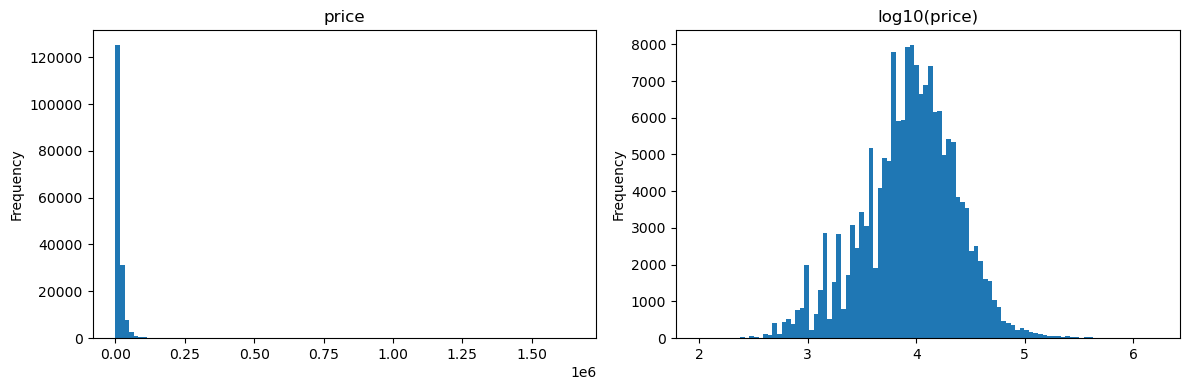

count     169236.0
mean       14104.0
std        20662.0
min          100.0
1%           695.0
25%         4990.0
50%         9395.0
75%        16995.0
99%        79950.0
max      1650000.0
Name: price, dtype: float64

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda["price"].plot.hist(bins=100, ax=axes[0], title="price")
np.log10(eda["price"]).plot.hist(bins=100, ax=axes[1], title="log10(price)")
plt.tight_layout()
plt.show()

eda["price"].describe(percentiles=[.01, .25, .5, .75, .99]).round(0)

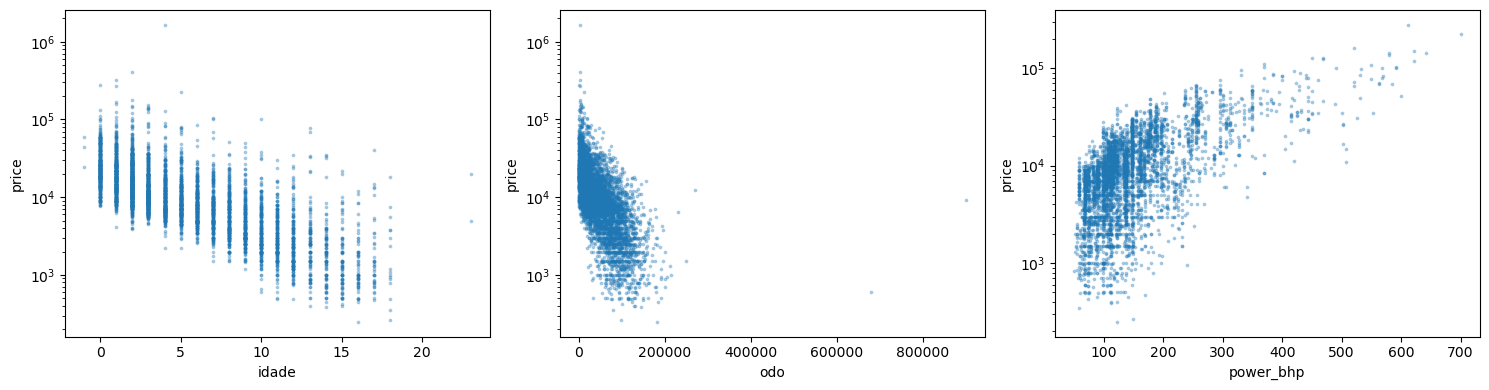

idade         -0.343933
odo           -0.328904
econ_mpg      -0.166858
doors         -0.152275
seats         -0.125222
listed_mo     -0.038701
disp           0.018878
listed_yr      0.101949
annual_tax     0.185979
length_mm      0.333384
first_reg      0.346075
pct_of_list    0.599356
power_bhp      0.695483
entry_price    0.796869
Name: price, dtype: float64

In [19]:
# Relação do preço com algumas numéricas (amostra para o gráfico ficar leve)
amostra = eda.sample(5000, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["idade", "odo", "power_bhp"]):
    ax.scatter(amostra[col], amostra["price"], s=3, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("price")
plt.tight_layout()
plt.show()

eda.select_dtypes("number").corr()["price"].drop("price").sort_values()

### Alvo 2: `gearbox`

In [20]:
print(eda["gearbox"].value_counts(normalize=True).round(3))

# Proporção de automáticos por algumas categorias
for col in ["fuel", "body"]:
    tab = (eda.assign(auto=eda["gearbox"].eq("Automatic"))
              .groupby(col)["auto"].agg(["mean", "size"])
              .query("size >= 100").sort_values("mean", ascending=False))
    print(tab.round(3), "\n")

gearbox
Manual            0.640
Automatic         0.359
Semi-Automatic    0.001
Name: proportion, dtype: float64
                                  mean   size
fuel                                         
Hybrid  Petrol/Electric Plug-in  1.000    462
Petrol Plug-in Hybrid            1.000    185
Electric                         0.994    703
Petrol Hybrid                    0.990    298
Hybrid  Petrol/Electric          0.967   3767
Diesel                           0.411  83053
Petrol                           0.262  81148 

              mean   size
body                     
Panel Van    0.769    221
Saloon       0.640  14542
Coupe        0.586  10901
SUV          0.501  39354
Estate       0.416  11533
Convertible  0.395   8846
Pickup       0.349   2455
MPV          0.293  13775
Combi Van    0.209    450
Hatchback    0.177  67035 



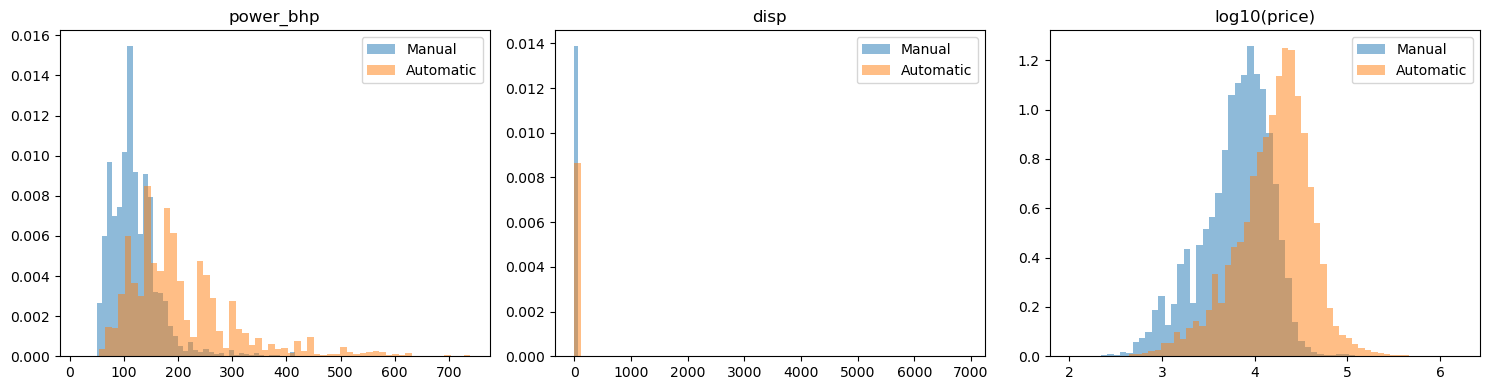

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["power_bhp", "disp", "price"]):
    for g in ["Manual", "Automatic"]:
        vals = eda.loc[eda["gearbox"] == g, col].dropna()
        if col == "price":
            vals = np.log10(vals)
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=g)
    ax.set_title(col if col != "price" else "log10(price)")
    ax.legend()
plt.tight_layout()
plt.show()

### Primeiras observações

- **170 mil anúncios, 21 colunas.** Várias colunas numéricas estão como texto (`price`, `odo`, `disp`, `econ_mpg`, `annual_tax`) e precisam de limpeza.
- **`price` tem 914 valores `"Uknown"`** — essas linhas não servem para treinar o modelo de preço. A distribuição é bem assimétrica; `log(price)` fica muito mais comportada.
- **`pct_of_list` = `price / entry_price`**: usa o próprio alvo, então é **vazamento** e não pode entrar no modelo de preço (nem estará disponível num anúncio novo).
- **`gearbox`**: ~64% Manual, ~36% Automatic, e só 110 `Semi-Automatic` (decidir se descarta ou agrupa). Potência, cilindrada e preço separam bem as classes.
- **Faltantes** de até ~18% em `annual_tax`, `econ_mpg`, `entry_price`, `power_bhp`, `length_mm` e `paint`.
- **Anomalias**: `listed_mo` tem um valor 17; `body` tem 5 linhas `"Manual"`; `fuel` tem variações de escrita do mesmo tipo (ex.: `Hybrid  Petrol/Electric` vs `Petrol Hybrid`); `odo` tem valores como `"1 mile"`.
- **Alta cardinalidade**: `ref_code` (513) e `maker` (88) exigem cuidado na codificação, especialmente porque o conjunto de avaliação tem composição diferente.

## Limpeza da base de dados




Na EDA encontramos vários problemas na base. Nesta parte, tratamos **um problema de cada vez**, sempre no mesmo ciclo:

1. **O que vimos** — a observação e a hipótese sobre a causa;
2. **Investigação** — código que testa a hipótese;
3. **Decisão** — o que fazemos e por quê.

Durante a investigação **não alteramos a base**: só olhamos. No final, todas as decisões são reunidas em uma única função, `limpar()`.

Por que uma função? Porque a **mesma limpeza precisa ser aplicada ao arquivo de avaliação** na FINAL — PREDICTION SECTION. Para isso dar certo, a função segue três regras:

- **Não aprende nada dos dados** (nenhuma média, mediana ou contagem). Assim, aplicá-la a um arquivo novo dá exatamente o mesmo tratamento, sem depender da composição da base.
- **Não apaga linhas.** Valores impossíveis viram `NaN`. Na avaliação precisamos prever *todos* os anúncios, então a limpeza não pode descartar nenhum.
- **Não quebra se faltar coluna.** 

In [22]:
import re

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)

(170150, 21)


### Problema 1 — `pct_of_list` 

**O que vimos:** o dicionário de dados define `pct_of_list` como `price / entry_price`. Se isso for verdade, essa coluna **contém o alvo** do Modelo 1: sabendo `pct_of_list` e `entry_price`, o preço sai por uma multiplicação.

**Decisão: remover `pct_of_list` da base, para os dois modelos.**

- **Modelo 1:** usar essa coluna é vazamento. O modelo teria um erro quase zero no treino, mas num anúncio novo essa coluna não existe (para calculá-la, precisaríamos saber o preço, que é justamente o que queremos sugerir).
- **Modelo 2:** a coluna carrega a informação do preço. Como vamos decidir mais adiante se o preço entra no modelo de câmbio, não faz sentido deixar ele entrar "escondido" por aqui.

In [24]:
# O dicionário diz que pct_of_list = price / entry_price. Vamos conferir.
preco_num = pd.to_numeric(df["price"], errors="coerce")
razao_recalculada = preco_num / df["entry_price"]

tem_os_dois = df["pct_of_list"].notna() & razao_recalculada.notna()
bate = (razao_recalculada[tem_os_dois] - df.loc[tem_os_dois, "pct_of_list"]).abs() < 0.001

print("linhas com pct_of_list preenchido:", tem_os_dois.sum())
print("% em que pct_of_list = price / entry_price:", round(bate.mean() * 100, 2))
print("linhas com price desconhecido mas pct_of_list preenchido:",
      (preco_num.isna() & df["pct_of_list"].notna()).sum())

linhas com pct_of_list preenchido: 143907
% em que pct_of_list = price / entry_price: 100.0
linhas com price desconhecido mas pct_of_list preenchido: 0


### Problema 2 — `price` como texto e preços extremos

**O que vimos:** `price` veio como texto, porque algumas linhas não têm número. A distribuição também é muito assimétrica: vai de £100 a £1,65 milhão.

**Perguntas:**
1. Quais valores não são número?
2. Os preços extremos são erros de digitação ou carros reais?

In [25]:
# Quais valores de price não são números?
nao_numericos = df.loc[preco_num.isna(), "price"]
print(nao_numericos.value_counts(dropna=False))

price
Uknown    914
Name: count, dtype: int64


In [26]:
# Os anúncios mais baratos e mais caros fazem sentido?
contexto = ["maker", "first_reg", "listed_yr", "odo", "entry_price", "price"]
aux = df.assign(price_num=preco_num).sort_values("price_num")

print("10 mais baratos:")
print(aux[contexto].head(10))
print("\n10 mais caros:")
print(aux.dropna(subset=["price_num"])[contexto].tail(10))

10 mais baratos:
             maker  first_reg  listed_yr     odo  entry_price price
142922    Vauxhall     2004.0       2018  115000       9825.0   100
148123    Vauxhall     2011.0       2018   70000       8940.0   100
90257      Renault     2002.0       2018   78451       7370.0   100
21563         Ford     2003.0       2018   61545       6370.0   100
17031         Ford     2004.0       2018   89000       9830.0   125
151680  Volkswagen     2001.0       2018  215000      10570.0   150
22350         Ford     2004.0       2018  100000       6632.0   150
90932      Renault     2006.0       2018     NaN       7350.0   175
114005       Smart     2002.0       2018   72941       6170.0   180
142816    Vauxhall     2001.0       2018  147000      10115.0   180

10 mais caros:
             maker  first_reg  listed_yr    odo  entry_price    price
84688      Porsche     2018.0       2018     50      77891.0   549995
6040       Ferrari     2011.0       2018  18668          NaN   599995
6043     

**Resultado:**

- O único valor não numérico é `"Uknown"` , em **914 linhas**.
- Os **mais baratos** (£100–£180) são, em sua maioria, carros populares de 2001–2006 com bastante quilometragem. São preços de "carro para desmanche", plausíveis. Um ou outro é suspeito (um Vauxhall de 2011 por £100), mas não há como provar que é erro.
- Os **mais caros** são Bugatti, Pagani, Koenigsegg e Ferrari: hipercarros reais, com preços reais.

**Decisões:**

- `"Uknown"` vira `NaN`. Essas 914 linhas **não servem para treinar o Modelo 1**, mas **continuam na base**: elas têm câmbio e servem para o Modelo 2.
- **Os preços extremos são mantidos.** Motivos:
  1. Não conseguimos distinguir com segurança o que é erro do que é carro barato de verdade;
  2. São muito poucos: menos de 20 anúncios abaixo de £200, em 169 mil;
  3. Vamos modelar `log(price)`, então os extremos não dominam o treino;
  4. Remover os carros de luxo só "esconderia" o problema. Preferimos deixá-los e **mostrar na análise de erros** que o modelo erra mais neles, o que vai para o escopo de validade.

### Problema 3 — Categorias de `gearbox`

**O que vimos:** além de `Automatic` e `Manual`, existe `Semi-Automatic`, e há linhas sem câmbio. O enunciado pede só duas classes para o modelo 2.

**Pergunta:** quem são os semiautomáticos? Eles se parecem mais com automáticos ou com manuais?

In [27]:
print(df["gearbox"].value_counts(dropna=False))
print("\nQuem são os Semi-Automatic:")
print(df.loc[df["gearbox"] == "Semi-Automatic", "maker"].value_counts().head(8))

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64

Quem são os Semi-Automatic:
maker
Porsche        33
Lamborghini    14
Bentley         9
Ford            9
Volkswagen      8
Hyundai         8
SKODA           5
Ferrari         5
Name: count, dtype: int64


**Resultado:** 108.838 manuais, 61.085 automáticos, **110 semiautomáticos** e **117 sem câmbio**. Os semiautomáticos são principalmente Porsche, Lamborghini, Bentley e Ferrari, e também Ford, Volkswagen, Skoda e Hyundai. Nessas marcas, "semiautomático" costuma ser o câmbio de dupla embreagem (PDK, DSG, Powershift).

**Decisões:**

- **`Semi-Automatic` → `Automatic`.** Esses câmbios **não têm pedal de embreagem**: para quem compra, funcionam como automáticos, e quem filtra "automático" no site esperaria encontrá-los. Como são 0,06% da base, a decisão quase não muda o modelo; o importante é ela ser coerente.
- **Criamos o alvo binário `auto`** (1 = Automatic, 0 = Manual).
- **As 117 linhas sem câmbio** não servem para treinar o Modelo 2, mas continuam na base (servem para o Modelo 1). Na avaliação, anúncios assim recebem previsão normalmente.

### Problema 4 — Colunas numéricas guardadas como texto

**O que vimos:** `odo`, `disp`, `econ_mpg` e `annual_tax` são números, mas vieram como texto por causa de sufixos (`L`, `mpg`, `mile`, `*`) e espaços.

**Pergunta:** quantos formatos diferentes existem? Se forem poucos e regulares, uma regra só resolve todas as colunas.

**Truque:** trocamos todo dígito por `9`. Assim `"6.8L"` e `"2.0L"` viram o mesmo padrão `"9.9L"`, e enxergamos só os formatos.

In [28]:
# Quais "formatos" aparecem em cada coluna? Trocamos todo dígito por 9 para ver só o padrão.
for col in ["odo", "disp", "econ_mpg", "annual_tax"]:
    formatos = df[col].dropna().astype(str).str.replace(r"\d", "9", regex=True)
    print(f"{col}: {formatos.value_counts().head(6).to_dict()}")

odo: {'99999': 118529, '9999': 23751, '999999': 19910, '99': 3694, '999': 2456, '9': 923}
disp: {'9.9L': 165970, '9.99L': 2198, '9999.9L': 838, '999.9L': 5}
econ_mpg: {'99.9 mpg': 141591, '999.9 mpg': 217, '9.9 mpg': 1}
annual_tax: {' 999': 81575, ' 99': 27659, ' 999*': 21189, ' 9': 8911, '*': 401, ' 9*': 129}


**Resultado:** os formatos são sempre "um número + algum sufixo": `9.9L`, `99.9 mpg`, ` 999*`, `9 mile`. Não há número escrito por extenso nem dois números na mesma célula.

**Decisão:** uma única regra para todas as colunas: **extrair o primeiro número que aparecer no texto**. O que não tiver número (como `"*"` sozinho ou `"Uknown"`) vira `NaN`.

A função abaixo faz isso com uma *expressão regular*: `-?` aceita um sinal negativo, `\d+` pega um ou mais dígitos e `\.?\d*` pega a parte decimal, se houver. Em seguida, testamos a função com um exemplo de cada formato.

In [34]:
def _para_numero(serie):
    """Extrai o primeiro número de um texto ('6.8L' -> 6.8, ' 140*' -> 140, '1 mile' -> 1)."""
    texto = serie.astype("string")
    numero = pd.to_numeric(texto.str.extract(r"(-?\d+\.?\d*)", expand=False), errors="coerce")
    return numero.astype("float64")


# Teste com um exemplo de cada formato
exemplos = pd.Series(["6.8L", "47.1 mpg", " 140*", " 30", "*", "1 mile", "60000", "Uknown", np.nan])
pd.DataFrame({"original": exemplos, "convertido": _para_numero(exemplos)})

,original,convertido
0,6.8L,6.8
1,47.1 mpg,47.1
2,140*,140.0
3,30,30.0
4,*,NaN
5,1 mile,1.0
6,60000,60000.0
7,Uknown,NaN
8,NaN,NaN


Todos os formatos foram convertidos corretamente.

Precisamos também de uma função para **padronizar textos**: alguns têm espaços nas pontas (`" 140*"`) ou espaços duplicados (`"Hybrid  Petrol/Electric"`, com dois espaços), e isso faria o mesmo valor ser tratado como duas categorias diferentes.

Detalhe técnico: usamos `.map` com uma função em vez do `.str.strip()` do pandas, porque se no arquivo de avaliação uma coluna vier inteiramente vazia, o pandas a lê como número e o `.str` dá erro.

In [30]:
def _limpar_texto(serie):
    """Tira espaços nas pontas e espaços repetidos ('Hybrid  Petrol' -> 'Hybrid Petrol').
    Funciona mesmo se a coluna vier vazia ou numérica no arquivo de avaliação."""
    return serie.map(lambda x: re.sub(r"\s+", " ", str(x)).strip() if pd.notna(x) else np.nan).astype("object")


exemplos = pd.Series(["Hybrid  Petrol/Electric", " 140*", "Petrol", np.nan])
pd.DataFrame({"original": exemplos.map(repr), "limpo": _limpar_texto(exemplos).map(repr)})

,original,limpo
0,'Hybrid Petrol/Electric','Hybrid Petrol/Electric'
1,' 140*','140*'
2,'Petrol','Petrol'
3,nan,nan


### Problema 5 — Cilindrada (`disp`)

**O que vimos:** depois de converter para número, vamos olhar a distribuição. Cilindradas de carros de passeio ficam tipicamente entre 0,6 e 8 litros.

In [35]:
disp_num = _para_numero(df["disp"])
print(disp_num.describe().round(2))
print("\nvalores >= 100:", (disp_num >= 100).sum())
print(df.loc[disp_num >= 100, "disp"].value_counts().head(8))

count    169011.00
mean         11.56
std         145.66
min           0.30
25%           1.40
50%           1.80
75%           2.00
max        6900.00
Name: disp, dtype: float64

valores >= 100: 843
disp
2000.0L    215
1600.0L    140
3000.0L     85
1400.0L     69
1000.0L     58
1200.0L     53
2200.0L     32
1500.0L     30
Name: count, dtype: int64


**Resultado:** a mediana é 1,8 L (normal), mas o máximo é 6.900 "litros", e **843 linhas têm valor ≥ 100**. Os valores mais comuns são `2000.0L`, `1600.0L` e `3000.0L`.

**Hipótese:** esses valores estão em **cilindradas (cc)**, com o sufixo `L` colocado por engano. `2000.0L` seria, na verdade, 2000 cc = 2,0 L.

**Como testar:** se a hipótese estiver certa, cada valor suspeito deve ser cerca de **1000 vezes** a cilindrada típica do mesmo modelo de carro (`ref_code`), calculada só com as linhas normais.

In [36]:
# Hipótese: os valores >= 100 estão em cc. Se for verdade, eles devem ser ~1000x a cilindrada
# típica do mesmo modelo de carro (ref_code), calculada só com as linhas "normais".
normais = disp_num < 100
mediana_por_ref = disp_num[normais].groupby(df.loc[normais, "ref_code"]).median()

suspeitos = disp_num >= 100
comparacao = pd.DataFrame({
    "disp_lido": disp_num[suspeitos],
    "mediana_do_ref_code": df.loc[suspeitos, "ref_code"].map(mediana_por_ref),
})
comparacao["razao"] = comparacao["disp_lido"] / comparacao["mediana_do_ref_code"]
print(comparacao["razao"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

count     843.0
mean     1013.2
std       147.7
min       600.0
10%       875.0
25%      1000.0
50%      1000.0
75%      1000.0
90%      1185.3
max      2200.0
Name: razao, dtype: float64


**Resultado:** a razão tem **mediana exatamente 1000**, e 80% dos casos ficam entre 875 e 1185. As variações em torno de 1000 são normais, porque o mesmo modelo de carro tem versões com motores diferentes. **Hipótese confirmada.**

**Decisão:** valores ≥ 100 são divididos por 1000.

**Próxima pergunta:** depois da correção, sobram valores pequenos demais? E como ficam os carros elétricos, que não têm motor a combustão?

In [37]:
# Depois de dividir por 1000, quais são os menores valores? E os elétricos?
disp_corrigido = disp_num.where(disp_num < 100, disp_num / 1000)
print("menores cilindradas:")
print(df.assign(disp_corrigido=disp_corrigido).nsmallest(5, "disp_corrigido")[["maker", "ref_code", "disp", "fuel"]])
print("\ncilindrada dos elétricos:")
print(df.loc[df["fuel"] == "Electric", "disp"].value_counts(dropna=False))

menores cilindradas:
                maker ref_code  disp    fuel
66439   Mercedes-Benz    M1074  0.3L  Petrol
113727          Smart    M1689  0.6L  Petrol
113737          Smart    M1689  0.6L  Petrol
113756          Smart    M1689  0.6L  Petrol
113761          Smart    M1689  0.6L  Petrol

cilindrada dos elétricos:
disp
NaN     691
2.0L      5
1.0L      4
4.0L      2
6.6L      1
Name: count, dtype: int64


**Resultado:**

- O menor valor é um Mercedes de **0,3 L**. Isso é impossível: o menor motor da base de verdade é o do Smart, com 0,6 L, que aparece logo em seguida.
- Dos 703 elétricos, **691 não têm cilindrada**. Isso é o correto, porque eles não têm motor a combustão.

**Decisões:**

- Cilindradas fora de **0,5 a 9 L** viram `NaN`.
- **Elétrico sem cilindrada recebe 0**, e não `NaN`. A diferença importa: `NaN` significa "não sabemos", enquanto 0 significa "sabemos que não tem motor". Para o modelo, é uma informação verdadeira e útil.
- Os 12 elétricos com cilindrada preenchida são mantidos como estão: são poucos e provavelmente híbridos cadastrados como elétricos.

### Problema 6 — Quilometragem (`odo`)

**O que vimos:** a quilometragem (em milhas) tem valores muito altos e um formato `"1 mile"`.

**Pergunta:** a partir de que ponto a quilometragem deixa de ser plausível?

In [38]:
odo_num = _para_numero(df["odo"])
print(odo_num.describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(0))
print("\nAnúncios com mais de 300 mil milhas:")
print(df.assign(odo_num=odo_num).query("odo_num > 300000")
        .sort_values("odo_num")[["maker", "first_reg", "body", "odo_num", "price"]])

count     169472.0
mean       48183.0
std        42992.0
min            0.0
1%            10.0
50%        39117.0
99%       159576.0
99.9%     210000.0
max      6363342.0
Name: odo, dtype: float64

Anúncios com mais de 300 mil milhas:
                             maker  first_reg         body    odo_num  price
68203                Mercedes-Benz     2009.0          MPV   304850.0   5200
17032                         Ford     2005.0    Hatchback   324000.0    999
44686                       Jaguar     2011.0       Saloon   328000.0   7995
94062                         SEAT     2010.0    Hatchback   328856.0   1985
57323   London Taxis International     2002.0          NaN   331337.0   1200
45985                          Kia     2007.0          MPV   345000.0    795
133511                      Toyota     2013.0          SUV   425000.0  13495
53791                   Land Rover     2014.0          SUV   478566.0  27995
22269                         Ford     2008.0    Hatchback   680421.0   

**Resultado:** 99% dos carros têm menos de 160 mil milhas. Acima de 300 mil, os casos se dividem em dois grupos:

- **Até ~480 mil:** um Toyota SUV por £13 mil, um Land Rover por £28 mil, um táxi londrino. São veículos de uso intenso, mas plausíveis.
- **A partir de 680 mil:** hatchbacks comuns, vendidos por £250 a £1.900, com 680 mil a **6,3 milhões** de milhas. Um carro comum raramente passa de 300 mil milhas na vida toda, e o salto de 478 mil para 680 mil separa bem os dois grupos. Provavelmente são erros de digitação (zeros a mais).

**Decisão:** quilometragem acima de **500 mil milhas** vira `NaN` (afeta 9 anúncios).

**Próxima pergunta:** e o `"1 mile"`? É erro ou carro zero?

In [39]:
# "1 mile": são carros novos?
um_mile = df["odo"] == "1 mile"
print("anúncios com '1 mile':", um_mile.sum())
print("anos entre registro e anúncio:")
print((df.loc[um_mile, "listed_yr"] - df.loc[um_mile, "first_reg"]).value_counts())

anúncios com '1 mile': 207
anos entre registro e anúncio:
 0.0    177
 1.0     15
-1.0     12
 3.0      1
 2.0      1
-3.0      1
Name: count, dtype: int64


**Resultado:** dos 207 anúncios com `"1 mile"`, 177 foram anunciados **no mesmo ano** do registro. São carros zero, com a quilometragem de entrega.

**Decisão:** manter. É um valor verdadeiro, e o conversor já transforma `"1 mile"` em 1.

### Problema 7 — O asterisco em `annual_tax`

**O que vimos:** cerca de 21 mil valores de imposto têm um asterisco (`" 140*"`). O dicionário diz "See note 3", mas **essa nota não veio no arquivo**.

**Hipótese:** em abril de 2017, o Reino Unido mudou o imposto anual de veículos (VED). Antes, o valor dependia da faixa de emissão de CO₂. Depois, carros novos passaram a pagar uma **taxa fixa**: £140 (gasolina/diesel), £130 (combustível alternativo, como híbridos) e £0 (elétricos). Se o asterisco marca o regime novo, ele deve aparecer **só em carros registrados a partir de 2017**, e **quase só com os valores 140, 130 e 0**.

In [40]:
tax_txt = _limpar_texto(df["annual_tax"])
tem_asterisco = tax_txt.str.contains("*", regex=False)

print("valores com asterisco:")
print(tax_txt[tem_asterisco == True].value_counts())
print("\nRegistrado a partir de 2017 x tem asterisco:")
print(pd.crosstab(df["first_reg"] >= 2017, tem_asterisco, rownames=["first_reg >= 2017"], colnames=["asterisco"]))

valores com asterisco:
annual_tax
140*    20063
130*     1126
*         401
0*        129
Name: count, dtype: int64

Registrado a partir de 2017 x tem asterisco:
asterisco           False  True 
first_reg >= 2017               
False              113658    103
True                 4487  21616


**Resultado:** as duas previsões da hipótese se confirmam.

- Os valores com asterisco são **apenas** `140*` (20.063), `130*` (1.126), `0*` (129) e `*` sozinho (401): exatamente as três taxas fixas do regime novo.
- Dos 21.719 anúncios com asterisco, **21.616 (99,5%)** são de carros registrados a partir de 2017.
- Há 4.487 carros de 2017 em diante **sem** asterisco. Isso também é coerente: são carros registrados entre janeiro e março de 2017, antes da mudança.

**Decisão:**

- O asterisco **não é erro**: ele indica o regime do imposto. Guardamos essa informação numa coluna nova, `tax_novo_regime` (1 = regime novo, 0 = antigo).
- O valor numérico do imposto também é mantido.
- A consequência disso para as features (o imposto só mede emissões no regime antigo) é explorada na Parte 3.


### Problema 8 — Ano de registro (`first_reg`)

**O que vimos:** existem anúncios em que o carro foi **registrado depois** do ano do anúncio, o que à primeira vista parece impossível. Também há um registro em 1900.

**Pergunta:** isso é erro de digitação, ou existe uma explicação real?

In [41]:
depois = df["first_reg"] > df["listed_yr"]
print("anúncios com first_reg > listed_yr:", depois.sum())
print("\nquantos anos 'no futuro':")
print((df.loc[depois, "first_reg"] - df.loc[depois, "listed_yr"]).value_counts())
print("\nquilometragem desses carros:")
print(_para_numero(df.loc[depois, "odo"]).describe().round(0))

anúncios com first_reg > listed_yr: 97

quantos anos 'no futuro':
1.0    89
2.0     7
3.0     1
Name: count, dtype: int64

quilometragem desses carros:
count       94.0
mean      1394.0
std       3058.0
min          1.0
25%         10.0
50%         20.0
75%        100.0
max      13310.0
Name: odo, dtype: float64


In [42]:
print("first_reg mais antigos:")
print(df["first_reg"].value_counts().sort_index().head(6))

first_reg mais antigos:
first_reg
1900.0      1
1970.0      2
1980.0      3
1990.0     17
1995.0     67
2000.0    510
Name: count, dtype: int64


**Resultado:** são 97 anúncios. Em 89 deles, a diferença é de só **1 ano**, e a quilometragem mediana é de **20 milhas**. Não parece erro: são **carros zero anunciados antes de serem emplacados** (estoque de concessionária ou pré-venda). Nossa primeira ideia era tratar esses casos como erro; os dados mostraram que não são.

Quanto aos anos antigos: 1970, 1980 e 1990 são carros clássicos plausíveis, mas **1900** é impossível (não havia carros à venda com registro nessa época).

**Decisões:**

- Os 97 anúncios **são mantidos**. Na Parte 3, a idade deles será 0.
- `first_reg` anterior a 1950 vira `NaN` (afeta só o registro de 1900).

### Problema 9 — Outros valores impossíveis

**O que vimos na EDA:** comprimento igual a 0, carros com 0 ou 7 portas, 1 ou 17 assentos, e um mês de anúncio igual a 17.

**Pergunta:** para cada caso, é erro ou um veículo incomum de verdade? Olhamos as linhas uma a uma.

In [43]:
print("length_mm < 2400:")
print(df.loc[df["length_mm"] < 2400, "length_mm"].value_counts())

print("\ndoors:", df["doors"].value_counts(dropna=False).sort_index().to_dict())
print("seats:", df["seats"].value_counts(dropna=False).sort_index().to_dict())

print("\nlinhas com portas ou assentos estranhos:")
estranhos = df["doors"].isin([0, 7]) | df["seats"].isin([1, 17])
print(df.loc[estranhos, ["maker", "body", "doors", "seats"]])

print("\nlisted_mo:", df["listed_mo"].value_counts().sort_index().to_dict())
print(df.loc[df["listed_mo"] > 12, ["listed_yr", "listed_mo"]])

length_mm < 2400:
length_mm
0.0       64
2337.0     1
Name: count, dtype: int64

doors: {0.0: 1, 2.0: 15336, 3.0: 21088, 4.0: 17930, 5.0: 112177, 6.0: 113, 7.0: 1, nan: 3504}
seats: {1.0: 1, 2.0: 5155, 3.0: 87, 4.0: 26858, 5.0: 121117, 6.0: 280, 7.0: 11261, 8.0: 458, 9.0: 99, 17.0: 3, nan: 4831}

linhas com portas ou assentos estranhos:
               maker       body  doors  seats
21173           Ford        MPV    7.0    7.0
68990  Mercedes-Benz        NaN    NaN   17.0
68994  Mercedes-Benz    Minibus    2.0   17.0
68995  Mercedes-Benz    Minibus    5.0   17.0
89972        Renault      Coupe    0.0    2.0
90712        Renault  Hatchback    3.0    1.0

listed_mo: {1: 3726, 2: 6218, 3: 13751, 4: 26618, 5: 43273, 6: 16200, 7: 22304, 8: 31884, 9: 1043, 10: 1524, 11: 1790, 12: 1818, 17: 1}
       listed_yr  listed_mo
80152       2012         17


**Resultado e decisões:**

| Caso | O que é | Decisão |
|---|---|---|
| `length_mm` = 0 (64 linhas) | Campo não preenchido gravado como 0 | `NaN` |
| `length_mm` = 2.337 (1 linha) | Microcarro, plausível | Mantém |
| `doors` = 0 (Renault Coupe) e `doors` = 7 (Ford MPV) | Impossíveis | `NaN` |
| `seats` = 1 (Renault Hatchback) | Impossível | `NaN` |
| `seats` = 17 (3 Mercedes) | São **micro-ônibus**: existem de verdade | Mantém |
| `listed_mo` = 17 (1 linha) | Mês inexistente (é também o único anúncio de 2012) | `NaN` |

Na função de limpeza, isso vira um **intervalo válido** para cada coluna: comprimento de 2.000 a 7.000 mm, portas de 2 a 6, assentos de 2 a 20 e mês de 1 a 12. Usar intervalos, em vez de corrigir linha por linha, faz a regra valer também para valores estranhos que apareçam no arquivo de avaliação.

### Problema 10 — Categorias: `fuel`, `body` e `paint`

**O que vimos:** o mesmo combustível aparece escrito de jeitos diferentes, e há carrocerias e cores com pouquíssimos anúncios.

**Por que isso importa:** categorias que significam a mesma coisa dividem a informação entre si, e categorias com poucas dezenas de linhas não dão ao modelo exemplos suficientes para aprender algo.

In [44]:
for col in ["fuel", "body", "paint"]:
    print(f"--- {col} ---")
    print(_limpar_texto(df[col]).value_counts(dropna=False).to_dict(), "\n")

--- fuel ---
{'Diesel': 83053, 'Petrol': 81148, 'Hybrid Petrol/Electric': 3767, 'Electric': 703, 'Hybrid Petrol/Electric Plug-in': 462, nan: 350, 'Petrol Hybrid': 298, 'Petrol Plug-in Hybrid': 185, 'Hybrid Diesel/Electric': 81, 'Diesel Hybrid': 34, 'Hybrid Diesel/Electric Plug-in': 34, 'Bi Fuel': 25, 'Petrol Ethanol': 8, 'Diesel Plug-in Hybrid': 2} 

--- body ---
{'Hatchback': 67035, 'SUV': 39354, 'Saloon': 14542, 'MPV': 13775, 'Estate': 11533, 'Coupe': 10901, 'Convertible': 8846, 'Pickup': 2455, nan: 710, 'Combi Van': 450, 'Panel Van': 221, 'Minibus': 95, 'Car Derived Van': 81, 'Limousine': 64, 'Window Van': 57, 'Camper': 24, 'Manual': 5, 'Tipper': 1, 'Chassis Cab': 1} 

--- paint ---
{'Black': 29928, 'Silver': 24670, 'Blue': 23899, 'Grey': 22778, 'White': 21197, nan: 19285, 'Red': 15956, 'Green': 3048, 'Brown': 1861, 'Yellow': 1776, 'Orange': 1695, 'Beige': 1011, 'Bronze': 739, 'Purple': 736, 'Gold': 691, 'Multicolour': 363, 'Pink': 217, 'Maroon': 131, 'Turquoise': 117, 'Burgundy': 2

**Resultado e decisões:**

- **`fuel`:** 13 grafias para 7 tipos reais. Por exemplo, `Hybrid Petrol/Electric` e `Petrol Hybrid` são a mesma coisa. Agrupamos em: Petrol, Diesel, Hybrid Petrol, Hybrid Diesel, Plug-in Hybrid, Electric e Other. `Bi Fuel` e `Petrol Ethanol` (33 anúncios ao todo) vão para Other. **Qualquer grafia nova que aparecer na avaliação também vira Other**, para o modelo não receber uma categoria que nunca viu.
- **`body`:** vans, micro-ônibus, camper e similares somam cerca de 930 anúncios espalhados em 9 categorias, e foram agrupados em `Van`. Limousine (64) vira Saloon, o formato mais próximo. **`Manual` em `body` (5 linhas) é claramente o câmbio digitado no campo errado** e vira `NaN`.
- **`paint`:** cores raras (Navy, Indigo, Magenta, Burgundy etc.) são agrupadas na cor mais próxima. A cor deve influenciar pouco nos dois modelos; o objetivo é só não manter categorias com 2 ou 5 anúncios.

In [45]:
# Variações de escrita do mesmo combustível -> uma categoria só
MAPA_FUEL = {
    "Petrol": "Petrol",
    "Diesel": "Diesel",
    "Electric": "Electric",
    "Hybrid Petrol/Electric": "Hybrid Petrol",
    "Petrol Hybrid": "Hybrid Petrol",
    "Hybrid Diesel/Electric": "Hybrid Diesel",
    "Diesel Hybrid": "Hybrid Diesel",
    "Hybrid Petrol/Electric Plug-in": "Plug-in Hybrid",
    "Petrol Plug-in Hybrid": "Plug-in Hybrid",
    "Hybrid Diesel/Electric Plug-in": "Plug-in Hybrid",
    "Diesel Plug-in Hybrid": "Plug-in Hybrid",
    "Bi Fuel": "Other",
    "Petrol Ethanol": "Other",
}

# Carrocerias comerciais raras viram "Van"; "Manual" em body é erro de preenchimento
MAPA_BODY = {
    "Combi Van": "Van", "Panel Van": "Van", "Window Van": "Van", "Car Derived Van": "Van",
    "Chassis Cab": "Van", "Tipper": "Van", "Minibus": "Van", "Camper": "Van",
    "Limousine": "Saloon",
    "Manual": np.nan,
}

# Cores raras agrupadas na cor mais próxima
MAPA_PAINT = {
    "Burgundy": "Red", "Maroon": "Red", "Navy": "Blue", "Indigo": "Blue",
    "Turquoise": "Blue", "Magenta": "Pink", "Bronze": "Brown", "Gold": "Yellow",
}

### Juntando tudo: a função `limpar()`

Agora transformamos as decisões dos 10 problemas em uma única função. Cada bloco da função tem um comentário indicando de qual problema veio a decisão.

Duas observações sobre a **ordem** dos passos:

- O **asterisco do imposto** precisa virar a coluna `tax_novo_regime` **antes** de o imposto ser convertido em número, senão a informação se perde.
- O **disp = 0 dos elétricos** só pode ser aplicado **depois** de padronizar o combustível, porque precisamos saber quem é `Electric` já com a grafia corrigida.

In [46]:
COLUNAS_ORIGINAIS = [
    "id", "ref_code", "maker", "first_reg", "listed_yr", "listed_mo", "odo", "disp",
    "gearbox", "fuel", "body", "doors", "seats", "paint", "power_bhp", "econ_mpg",
    "length_mm", "annual_tax", "entry_price", "pct_of_list", "price",
]


def _fora_do_intervalo(serie, minimo, maximo):
    """Troca por NaN os valores fora de [minimo, maximo]."""
    return serie.where(serie.between(minimo, maximo))


def limpar(df_bruto):
    """Aplica todas as decisões de limpeza. Não remove linhas e não aprende nada dos dados."""
    df = df_bruto.copy()

    # 0) Garante que todas as colunas existem (o arquivo de avaliação pode não ter os alvos)
    for col in COLUNAS_ORIGINAIS:
        if col not in df.columns:
            df[col] = np.nan

    # 0) Textos padronizados (espaços)
    for col in ["ref_code", "maker", "gearbox", "fuel", "body", "paint", "annual_tax"]:
        df[col] = _limpar_texto(df[col])

    # Problema 1) pct_of_list é o alvo disfarçado
    df = df.drop(columns=["pct_of_list"])

    # Problema 2) price: "Uknown" vira NaN; extremos são mantidos
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # Problema 3) gearbox: Semi-Automatic conta como Automatic; alvo binário 1/0
    df["gearbox"] = df["gearbox"].replace({"Semi-Automatic": "Automatic"})
    df["auto"] = df["gearbox"].map({"Automatic": 1.0, "Manual": 0.0})

    # Problema 4) numéricas guardadas como texto
    df["odo"] = _para_numero(df["odo"])
    df["disp"] = _para_numero(df["disp"])
    df["econ_mpg"] = _para_numero(df["econ_mpg"])

    # Problema 7) asterisco do imposto vira flag ANTES de converter o imposto em número
    df["tax_novo_regime"] = df["annual_tax"].map(lambda x: float("*" in x) if pd.notna(x) else np.nan)
    df["annual_tax"] = _para_numero(df["annual_tax"])

    # Problema 5) cilindrada em cc -> litros; fora de 0,5-9 L vira NaN
    df["disp"] = df["disp"].where(df["disp"] < 100, df["disp"] / 1000)
    df["disp"] = _fora_do_intervalo(df["disp"], 0.5, 9.0)

    # Problema 6) quilometragem impossível
    df["odo"] = _fora_do_intervalo(df["odo"], 0, 500_000)

    # Problemas 8 e 9) valores impossíveis
    df["first_reg"] = _fora_do_intervalo(df["first_reg"], 1950, 2030)
    df["length_mm"] = _fora_do_intervalo(df["length_mm"], 2_000, 7_000)
    df["doors"] = _fora_do_intervalo(df["doors"], 2, 6)
    df["seats"] = _fora_do_intervalo(df["seats"], 2, 20)
    df["listed_mo"] = _fora_do_intervalo(df["listed_mo"], 1, 12)

    # Problema 10) categorias (grafia desconhecida de combustível vira "Other")
    df["fuel"] = df["fuel"].map(lambda x: MAPA_FUEL.get(x, "Other") if pd.notna(x) else np.nan)
    df["body"] = df["body"].replace(MAPA_BODY)
    df["paint"] = df["paint"].replace(MAPA_PAINT)

    # Problema 5, de novo) só agora sabemos o combustível já padronizado
    df.loc[df["fuel"].eq("Electric") & df["disp"].isna(), "disp"] = 0.0

    return df

### Verificação 1: a função faz o que decidimos?

Aplicamos `limpar()` à base e conferimos cada decisão com uma checagem automática (`assert`). Se alguma decisão não tiver sido aplicada, o notebook **para com erro** nesta célula. Isso protege contra alterações acidentais na função mais tarde.

Também comparamos o percentual de faltantes antes e depois: os aumentos devem corresponder **apenas** aos valores impossíveis que decidimos anular.

In [47]:
df_limpo = limpar(df)

# Cada checagem confere uma decisão contra o que vimos na investigação
assert len(df_limpo) == len(df), "a limpeza não pode remover linhas"
assert "pct_of_list" not in df_limpo.columns
assert df_limpo["price"].isna().sum() == 914
assert set(df_limpo["gearbox"].dropna()) == {"Automatic", "Manual"}
assert df_limpo["disp"].max() <= 9
assert df_limpo["odo"].max() <= 500_000
assert df_limpo["fuel"].nunique() == 7
print("todas as checagens passaram")

comparacao = pd.DataFrame({
    "faltante_antes_%": df.isna().mean().mul(100),
    "faltante_depois_%": df_limpo.isna().mean().mul(100),
}).dropna().round(2)
comparacao[comparacao.max(axis=1) > 0]

todas as checagens passaram


,faltante_antes_%,faltante_depois_%
annual_tax,17.80,18.04
body,0.42,0.42
disp,0.67,0.26
doors,2.06,2.06
econ_mpg,16.66,16.66
entry_price,15.16,15.16
fuel,0.21,0.21
gearbox,0.07,0.07
length_mm,10.59,10.62
odo,0.40,0.40


**Leitura:** as mudanças nos faltantes são exatamente as esperadas.

- `price` passa de 0% para 0,54%: são os 914 `"Uknown"`.
- `disp` **diminui** de 0,67% para 0,26%, porque os elétricos ganharam 0.
- `annual_tax` sobe um pouco, por causa dos `"*"` sem número.
- `length_mm` sobe um pouco, por causa dos comprimentos iguais a zero.
- As demais colunas praticamente não mudam.

### Verificação 2: a função aguenta um arquivo "diferente"?

O enunciado avisa que o conjunto de avaliação tem outra composição. Simulamos o pior cenário razoável: um arquivo **sem as colunas-alvo**, com um **modelo de carro que nunca vimos**, um **combustível com grafia nova** e uma **coluna inteira vazia**.

In [48]:
# Simula um arquivo de avaliação "diferente": sem as colunas-alvo, com um modelo de carro
# nunca visto, um combustível com grafia nova e uma coluna inteira vazia.
avaliacao_fake = df.sample(300, random_state=0).drop(columns=["price", "gearbox", "pct_of_list"])
avaliacao_fake.loc[avaliacao_fake.index[:10], "ref_code"] = "M_NOVO"
avaliacao_fake.loc[avaliacao_fake.index[:5], "fuel"] = "Hydrogen"
avaliacao_fake["annual_tax"] = np.nan

teste = limpar(avaliacao_fake)
print("linhas:", len(avaliacao_fake), "->", len(teste))
print("colunas-alvo criadas vazias:", teste["price"].isna().all(), teste["auto"].isna().all())
print("combustível novo virou:", list(teste.loc[teste.index[:5], "fuel"].unique()))

linhas: 300 -> 300
colunas-alvo criadas vazias: True True
combustível novo virou: ['Other']


C:\Users\rehle\AppData\Local\Temp\ipykernel_21832\1663673964.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gearbox"] = df["gearbox"].replace({"Semi-Automatic": "Automatic"})


**Resultado:** nenhuma linha foi perdida, as colunas-alvo foram criadas vazias e o combustível desconhecido virou `Other`. A limpeza está pronta para ser reaproveitada na FINAL — PREDICTION SECTION.

### Resumo das decisões de limpeza

| # | Problema | Decisão | Evidência |
|---|---|---|---|
| 1 | `pct_of_list` | Removida | É `price / entry_price` em 100% das linhas |
| 2 | `price = "Uknown"` | `NaN` (fora do treino do Modelo 1) | 914 linhas |
| 2 | Preços extremos | Mantidos | Carros velhos baratos e hipercarros reais |
| 3 | `Semi-Automatic` | → `Automatic` | Câmbios sem embreagem (PDK, DSG); 0,06% da base |
| 4 | Números como texto | Extrair o primeiro número | Formatos sempre "número + sufixo" |
| 5 | `disp` ≥ 100 | ÷ 1000 | Razão com o próprio `ref_code` = 1000 |
| 5 | Elétricos sem `disp` | 0 | Não têm motor a combustão |
| 6 | `odo` > 500 mil | `NaN` | Salto de 478 mil para 680 mil, em carros baratos |
| 7 | Asterisco no imposto | Flag `tax_novo_regime` | 99,5% em carros de 2017+; só taxas fixas |
| 8 | `first_reg` > `listed_yr` | **Mantidos** | Carros zero (mediana de 20 milhas) |
| 9 | Portas, assentos, comprimento, mês | Intervalos válidos | Linhas inspecionadas uma a uma |
| 10 | Categorias | Grafias unificadas, raras agrupadas | Contagens por categoria |

# Parte 3 — Feature engineering

Agora, em vez de corrigir problemas, **criamos informação nova** a partir das colunas que já existem.

### A ideia do bolo

Imagine prever se um bolo vai ficar fofo sabendo a **massa** e o **volume** da massa crua. Cada coluna sozinha diz pouco: um bolo pesado pode ser só um bolo grande. O que importa é a **densidade** (massa ÷ volume), que junta as duas colunas num número com significado.

Nos carros, a pergunta é a mesma: **que pares de colunas, combinados, dizem algo que nenhuma das duas diz sozinha?** Por exemplo, a potência **por litro** de motor separa a versão "forte" e a versão "fraca" de um mesmo motor 2.0.

Daqui em diante, chamamos as colunas criadas dessa forma de **features combinadas** (no código, a lista `FEATURES_COMBINADAS`).

**Por que o modelo não descobre isso sozinho?** Os modelos de árvore cortam **uma coluna de cada vez** ("potência > 150?", depois "cilindrada < 2,0?"). Para imitar uma divisão, eles precisam de uma "escada" com muitos cortes, cada degrau com poucos dados. Com a razão pronta, um corte basta. Somas e subtrações são mais fáceis de imitar, como veremos na Feature 1.

### Como decidimos

O ciclo é o mesmo da limpeza: **hipótese → teste → decisão**. O teste tem duas partes:

1. **Olhar descritivo:** a feature se relaciona com o alvo de um jeito que faz sentido?
2. **Régua "com e sem":** treinamos um modelo rápido **sem** e **com** a feature e comparamos o erro na validação. Isso responde a uma pergunta que a correlação não responde: *a feature traz informação nova, ou só repete o que as outras colunas já dizem?*

Uma feature só entra se passar pela régua. **Features testadas e descartadas também são resultado** e ficam registradas.

## A régua "com e sem"

- **Modelo:** `HistGradientBoosting` (árvores), o mesmo tipo de modelo que pretendemos usar. Ele recebe as colunas numéricas limpas e `maker`, `fuel` e `body` como categóricas. `ref_code` fica de fora **só na régua**, porque tem 513 categorias, acima do limite desse modelo; o efeito do modelo de carro é tratado nas Features 10 e 11.
- **Dados:** uma amostra fixa de 40 mil anúncios por alvo (para rodar rápido na apresentação) e 4 divisões treino/validação, **as mesmas** dos dois lados da comparação.
- **Erro do preço:** RMSE de `log(price)`. Em log, 0,20 corresponde a errar cerca de 20% para cima ou para baixo. Diferenças menores que ~0,002 estão dentro do ruído.
- **Erro do câmbio:** *log loss*, que pune probabilidades confiantes e erradas. É a métrica certa porque o formulário vai mostrar a **probabilidade** de ser automático.
- **Dois tipos de divisão:** `"aleatoria"` (o modelo de carro aparece no treino e na validação) e `"ref_code"` (nenhum modelo de carro da validação aparece no treino). A segunda simula **carros inéditos** no conjunto de avaliação, que tem composição diferente.
- **Critério:** a feature entra se reduzir o erro **na média e em pelo menos 3 das 4 divisões**.

O erro "sem" de cada combinação é guardado num cache (`_cache`), para não ser recalculado a cada teste.

In [49]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import log_loss, root_mean_squared_error
from sklearn.model_selection import GroupKFold, KFold

aux = df_limpo.copy()
aux["log_price"] = np.log(aux["price"])
for col in ["maker", "fuel", "body"]:
    aux[col] = aux[col].astype("category")

# O que o modelo já recebe antes de qualquer feature nova
BASE = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg", "length_mm",
        "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price", "maker", "fuel", "body"]

# Amostras sorteadas uma única vez, para todos os testes serem comparáveis
idx_preco = aux[aux["price"].notna()].sample(40_000, random_state=0).index
idx_cambio = aux[aux["auto"].notna()].sample(40_000, random_state=0).index

_cache = {}


def _erros(d, alvo, colunas, divisoes, preparo=None):
    """Erro de validação em cada divisão, treinando só com `colunas`."""
    erros = []
    for i_tr, i_va in divisoes:
        tr, va = d.iloc[i_tr], d.iloc[i_va]
        if preparo is not None:  # features que aprendem com o treino (Features 10 e 11)
            tr, va = preparo(tr, va)
        if alvo == "log_price":
            m = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(root_mean_squared_error(va[alvo], m.predict(va[colunas])))
        else:
            m = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(log_loss(va[alvo], m.predict_proba(va[colunas])[:, 1]))
    return np.array(erros)


def testar(novas, base=BASE, divisao="aleatoria", preparo=None):
    """Compara o erro de validação SEM e COM as features `novas`, nos dois modelos.

    divisao="aleatoria": divisões sorteadas
    divisao="ref_code":  nenhum modelo de carro da validação aparece no treino
    preparo: função (treino, validação) -> (treino, validação), aplicada só no lado "com"
    """
    linhas = []
    for nome, alvo, idx in [("preço", "log_price", idx_preco), ("câmbio", "auto", idx_cambio)]:
        d = aux.loc[idx]
        if divisao == "aleatoria":
            divisoes = list(KFold(4, shuffle=True, random_state=0).split(d))
        else:
            divisoes = list(GroupKFold(4).split(d, groups=d["ref_code"]))

        chave = (alvo, tuple(base), divisao)
        if chave not in _cache:
            _cache[chave] = _erros(d, alvo, base, divisoes)
        sem = _cache[chave]
        com = _erros(d, alvo, base + novas, divisoes, preparo)

        linhas.append({
            "modelo": nome,
            "erro_sem": sem.mean(),
            "erro_com": com.mean(),
            "diferença": com.mean() - sem.mean(),
            "divisões_que_melhoraram": f"{(com < sem).sum()}/4",
        })
    return pd.DataFrame(linhas).set_index("modelo").round(4)

## Feature 1 — Idade do carro no momento do anúncio

**Hipótese:** o que define a desvalorização não é o ano de registro em si, e sim **quantos anos o carro tinha quando foi anunciado**. Um carro de 2015 anunciado em 2016 é seminovo; o mesmo carro anunciado em 2021 já tem 6 anos. É uma feature combinada feita com uma **subtração**: `listed_yr − first_reg`.

Detalhes da conta: usamos o **mês** do anúncio (`t_anuncio` = ano + fração do mês) e, como `first_reg` só tem o ano, assumimos o **meio do ano** de registro (+0,5). Idades negativas (os carros zero do Problema 8) viram **0**.

In [50]:
mes = aux["listed_mo"].fillna(6.5)
aux["t_anuncio"] = aux["listed_yr"] + (mes - 1) / 12
aux["idade"] = (aux["t_anuncio"] - (aux["first_reg"] + 0.5)).clip(lower=0)

print("anos de anúncio:", aux["listed_yr"].value_counts().sort_index().to_dict())
print("\nano de registro dos anúncios de 2021:", aux.loc[aux["listed_yr"] == 2021, "first_reg"].value_counts().to_dict())

print("\nPreço mediano de carros registrados em 2015, por ano do anúncio:")
print(aux[aux["first_reg"] == 2015].groupby("listed_yr")["price"].agg(["median", "size"]))

print("\nPreço mediano por idade no anúncio (anos inteiros):")
print(aux.groupby(aux["idade"].round().clip(upper=15))["price"].median().round(0).to_dict())

anos de anúncio: {2012: 1, 2014: 15, 2015: 60, 2016: 342, 2017: 7056, 2018: 152652, 2019: 72, 2020: 780, 2021: 9172}

ano de registro dos anúncios de 2021: {2019.0: 9172}

Preço mediano de carros registrados em 2015, por ano do anúncio:
            median   size
listed_yr                
2016       15642.5     18
2017       16699.0    435
2018       11000.0  18350

Preço mediano por idade no anúncio (anos inteiros):
{0.0: 22845.0, 1.0: 17999.0, 2.0: 15954.0, 3.0: 11000.0, 4.0: 9655.0, 5.0: 8350.0, 6.0: 7270.0, 7.0: 6295.0, 8.0: 5295.0, 9.0: 4295.0, 10.0: 3295.0, 11.0: 2800.0, 12.0: 2300.0, 13.0: 1995.0, 14.0: 1850.0, 15.0: 1299.0}


**Resultado do olhar descritivo:**

- **90% dos anúncios são de 2018.** Os 9.172 anúncios de 2021 são **todos de carros registrados em 2019**. É um bloco bem diferente do resto da base, e um forte candidato a se parecer com o conjunto de avaliação.
- Carros registrados em 2015 têm preço mediano de £16.699 quando anunciados em 2017 e de £11.000 quando anunciados em 2018: mesmo ano de registro, preços bem diferentes.
- O preço cai de forma clara e contínua com a idade: £22.845 com 0 anos, £11.000 com 3 e £3.295 com 10.

A idade claramente se relaciona com o preço. Mas a régua faz outra pergunta: **o modelo já não chega nisso sozinho?**

In [51]:
testar(["idade"])

,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1949,-0.0001,2/4
câmbio,0.2406,0.2406,-0.0000,2/4


**Resultado da régua:** nada muda (−0,0001 no preço, 0 no câmbio, melhora em só 2 de 4 divisões). O modelo já recebe `first_reg` e `listed_yr`, e como 90% dos anúncios são de 2018, `first_reg` sozinho já diz praticamente a idade. Uma subtração é o tipo de conta que a árvore imita com facilidade.

Talvez a idade só faça diferença quando o **ano do anúncio muda**, que é justamente o risco do conjunto de avaliação. Testamos esse cenário: treinamos com anúncios até 2020 e validamos no bloco de 2021.

In [52]:
# Treina com anúncios até 2020 e valida no bloco de 2021 (todos registrados em 2019)
treino_t = aux[(aux["listed_yr"] < 2021) & aux["price"].notna()].sample(60_000, random_state=0)
valid_t = aux[(aux["listed_yr"] == 2021) & aux["price"].notna()]

for nome, colunas in [("sem idade", BASE), ("com idade", BASE + ["idade"])]:
    m = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
    m.fit(treino_t[colunas], treino_t["log_price"])
    erro = root_mean_squared_error(valid_t["log_price"], m.predict(valid_t[colunas]))
    print(f"{nome}: RMSE de log(price) no bloco de 2021 = {erro:.4f}")

sem idade: RMSE de log(price) no bloco de 2021 = 0.2310
com idade: RMSE de log(price) no bloco de 2021 = 0.2318


**Resultado:** também não ajuda (0,2310 sem idade, 0,2318 com).

**Decisão:** a `idade` **não entra nos modelos**. Ela continua sendo calculada em `criar_features()` para a **análise de erros** (por exemplo, "o modelo erra mais em carros com mais de 15 anos?"), onde é bem mais fácil de interpretar que o ano de registro.

*Lição para as próximas features:* uma combinação só traz ganho se for algo que o modelo **não consegue montar sozinho**. A régua existe para separar uma coisa da outra.

## Feature 2 — Quilometragem por ano

**Hipótese:** 60 mil milhas num carro de 2 anos indicam uso intenso; num carro de 10 anos, uso leve. A quilometragem **por ano** (`odo ÷ idade`) mediria a intensidade de uso e talvez explicasse o preço melhor que a quilometragem total.

**Teste descritivo:** dentro de faixas de idade parecida, comparamos a correlação do preço com a quilometragem total e com a quilometragem por ano. Usamos a correlação de **Spearman**, que mede se uma variável sobe quando a outra sobe (ou desce), mesmo que a relação não seja uma reta. Carros com menos de 6 meses usam 0,5 ano no denominador, para não dividir por quase zero.

In [53]:
aux["odo_por_ano"] = aux["odo"] / aux["idade"].clip(lower=0.5)
faixas = pd.cut(aux["idade"], [0, 3, 6, 9, 12])

print(aux.groupby(faixas, observed=True).apply(lambda g: pd.Series({
    "spearman(price, odo)": g["price"].corr(g["odo"], method="spearman"),
    "spearman(price, odo_por_ano)": g["price"].corr(g["odo_por_ano"], method="spearman"),
})).round(3))

testar(["odo_por_ano"])

         spearman(price, odo)  spearman(price, odo_por_ano)
idade                                                      
(0, 3]                 -0.276                        -0.104
(3, 6]                 -0.118                        -0.035
(6, 9]                 -0.199                        -0.132
(9, 12]                -0.216                        -0.161


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1952,0.0002,1/4
câmbio,0.2406,0.2435,0.0028,0/4


**Resultado:** a hipótese não se confirmou. Em todas as faixas de idade, a quilometragem total tem relação mais forte com o preço (de −0,12 a −0,28) do que a quilometragem por ano (de −0,04 a −0,16). Na régua, `odo_por_ano` **piora** os dois modelos: +0,0002 no preço e +0,0028 no câmbio, com piora nas 4 divisões. O comprador parece olhar o número no painel, não a intensidade de uso.

**Decisão: descartar `odo_por_ano`.**

## Feature 3 — Potência por litro

**Hipótese:** o mesmo motor 2.0 pode render 140 cv numa versão comum e 250 cv numa versão esportiva ou turbo. A **potência por litro** (`power_bhp ÷ disp`) separaria essas versões. Versões mais fortes costumam ser mais caras e, com frequência, automáticas.

**Teste descritivo:** para isolar o efeito, olhamos só motores 2.0 L e comparamos as faixas de potência por litro. Nos elétricos (cilindrada 0), a feature fica `NaN`, para não dividir por zero.

In [54]:
aux["bhp_por_litro"] = aux["power_bhp"] / aux["disp"].where(aux["disp"] > 0)
motor_2l = aux[aux["disp"] == 2.0]

print("Motores 2.0L, por faixa de potência por litro:")
print(motor_2l.groupby(pd.qcut(motor_2l["bhp_por_litro"], 4), observed=True)
              .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
              .round(2))

testar(["bhp_por_litro"])

Motores 2.0L, por faixa de potência por litro:
                pct_automatico  preco_mediano      n
bhp_por_litro                                       
(36.999, 69.0]            0.20         6995.0  10095
(69.0, 75.0]              0.30        12400.0   7711
(75.0, 89.0]              0.45        12200.0   8871
(89.0, 188.0]             0.68        21395.0   7882


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1938,-0.0012,4/4
câmbio,0.2406,0.2372,-0.0034,4/4


**Resultado:** com a cilindrada fixa em 2.0 L, a fatia de automáticos sobe de **20% para 68%** e o preço mediano de **£7 mil para £21 mil** entre a faixa mais fraca e a mais forte. Na régua, é a primeira feature que melhora **os dois modelos nas 4 divisões** (preço −0,0012; câmbio −0,0034). Ao contrário da idade, a árvore não consegue imitar essa divisão com facilidade.

**Decisão: criar `bhp_por_litro`.**

## Feature 4 — Consumo × cilindrada

**Hipótese:** o consumo (`econ_mpg`) mistura duas coisas: o **tamanho** do motor (motor grande gasta mais) e a **eficiência** do conjunto. Fazer 50 mpg com um motor 1.2 é comum; fazer 50 mpg com um motor 3.0 indica um conjunto moderno e eficiente. Multiplicar pelo tamanho do motor (`econ_mpg × disp`) "desconta" o tamanho e deixa a eficiência.

Por que isso ajudaria a prever o **câmbio**: o câmbio faz parte do conjunto que gasta combustível. A mesma motorização costuma ter consumo oficial diferente na versão manual e na automática, e isso deveria aparecer aqui.

**Teste descritivo:** % de automáticos por faixa de consumo, comparando `econ_mpg` sozinho com `econ_mpg × disp`.

In [55]:
aux["mpg_x_litro"] = aux["econ_mpg"] * aux["disp"]

comparacao_mpg = pd.DataFrame({
    "% auto por faixa de econ_mpg": aux.groupby(pd.qcut(aux["econ_mpg"], 5), observed=True)["auto"].mean().values,
    "% auto por faixa de mpg_x_litro": aux.groupby(pd.qcut(aux["mpg_x_litro"], 5), observed=True)["auto"].mean().values,
}, index=["1ª (menor)", "2ª", "3ª", "4ª", "5ª (maior)"]).round(3)
print(comparacao_mpg)

testar(["mpg_x_litro"])

            % auto por faixa de econ_mpg  % auto por faixa de mpg_x_litro
1ª (menor)                         0.591                            0.144
2ª                                 0.334                            0.195
3ª                                 0.293                            0.365
4ª                                 0.175                            0.374
5ª (maior)                         0.228                            0.555


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0004,4/4
câmbio,0.2406,0.2323,-0.0083,4/4


**Resultado:** o consumo sozinho conta uma história confusa. A faixa que **mais gasta** tem 59% de automáticos, mas a relação não é contínua (a 5ª faixa tem mais automáticos que a 4ª), porque mistura motores grandes com motores ineficientes. Com `mpg_x_litro`, a relação fica limpa e sempre crescente: de **14% para 56%** de automáticos.

Na régua, é o maior ganho no câmbio até aqui: **−0,0083 (3,4% do erro), nas 4 divisões**. No preço, o ganho é pequeno (−0,0004), mas também aparece nas 4 divisões.

**Decisão: criar `mpg_x_litro`.**

## Feature 5 — Potência × consumo

**Hipótese:** em geral, potência e economia andam em sentidos opostos. Um carro **potente e econômico ao mesmo tempo** (`power_bhp × econ_mpg` alto) indica tecnologia mais nova: turbo moderno, híbrido, câmbio automático de muitas marchas. Um carro fraco e beberrão indica um projeto antigo.

In [56]:
aux["bhp_x_mpg"] = aux["power_bhp"] * aux["econ_mpg"]

print("% automático e preço mediano por faixa de potência × consumo:")
print(aux.groupby(pd.qcut(aux["bhp_x_mpg"], 5), observed=True)
         .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
         .round(2))

testar(["bhp_x_mpg"])

% automático e preço mediano por faixa de potência × consumo:
                    pct_automatico  preco_mediano      n
bhp_x_mpg                                               
(2171.999, 4592.0]            0.12         3295.0  28366
(4592.0, 5947.2]              0.21         5995.0  28361
(5947.2, 7318.8]              0.25         8000.0  28369
(7318.8, 9087.2]              0.34        12000.0  28638
(9087.2, 53570.0]             0.72        21799.0  28075


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1941,-0.0009,3/4
câmbio,0.2406,0.2327,-0.0079,4/4


**Resultado:** entre a faixa mais baixa e a mais alta, a fatia de automáticos sobe de **12% para 72%** e o preço mediano de **£3,3 mil para £21,8 mil**. Na régua, o câmbio melhora −0,0079 (nas 4 divisões) e o preço −0,0009 (em 3 de 4).

**Decisão: criar `bhp_x_mpg`.**

## Feature 6 — Motor em relação ao tamanho do carro

**Hipótese:** não temos o **peso** do carro, que seria o denominador ideal ("potência por kg"). O comprimento é o substituto mais próximo. Duas razões:

- `bhp_por_metro` = potência ÷ comprimento: carro pequeno e potente = esportivo (caro, mais automático); carro grande e fraco = utilitário ou van.
- `litro_por_metro` = cilindrada ÷ comprimento: motor grande para o tamanho do carro.

In [57]:
aux["bhp_por_metro"] = aux["power_bhp"] / (aux["length_mm"] / 1000)
aux["litro_por_metro"] = aux["disp"] / (aux["length_mm"] / 1000)

print("% automático e preço mediano por faixa de potência por metro:")
print(aux.groupby(pd.qcut(aux["bhp_por_metro"], 5), observed=True)
         .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
         .round(2))

pd.concat({"bhp_por_metro": testar(["bhp_por_metro"]),
           "litro_por_metro": testar(["litro_por_metro"])})

% automático e preço mediano por faixa de potência por metro:
                  pct_automatico  preco_mediano      n
bhp_por_metro                                         
(7.273, 22.151]             0.06         4800.0  29157
(22.151, 26.345]            0.18         6895.0  29195
(26.345, 31.298]            0.21         9070.0  29125
(31.298, 39.71]             0.44        11250.0  29232
(39.71, 158.077]            0.76        20695.0  29053


erro_sem  erro_com  diferença divisões_que_melhoraram
                modelo                                                       
bhp_por_metro   preço     0.1950    0.1943    -0.0006                     4/4
                câmbio    0.2406    0.2384    -0.0022                     4/4
litro_por_metro preço     0.1950    0.1942    -0.0008                     3/4
                câmbio    0.2406    0.2401    -0.0005                     3/4

**Resultado:**

- `bhp_por_metro`: os automáticos vão de **6% para 76%** e o preço mediano de £4,8 mil para £20,7 mil entre a faixa mais baixa e a mais alta. Na régua, melhora os dois modelos nas 4 divisões (preço −0,0006; câmbio −0,0022).
- `litro_por_metro`: passa no critério por pouco (−0,0008 e −0,0005, em 3 de 4 divisões). É um ganho dentro do ruído; a palavra final fica com o teste do grupo, logo abaixo.

**Decisão: criar as duas.**

## Feature 7 — Preço de tabela por cavalo

**Hipótese:** `entry_price ÷ power_bhp` diz **quanto cada cavalo custava novo**. Marcas premium cobram mais pela mesma potência; carros populares, menos. Isso mediria o "prestígio" do modelo, que segura o preço de revenda.

In [58]:
aux["tabela_por_bhp"] = aux["entry_price"] / aux["power_bhp"]

print("Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):")
grandes = aux["maker"].value_counts()[lambda s: s >= 1000].index
print(aux[aux["maker"].isin(grandes)].groupby("maker", observed=True)["tabela_por_bhp"]
         .median().sort_values().round(0).to_dict())

testar(["tabela_por_bhp"])

Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):
{'Dacia': 83.0, 'Vauxhall': 112.0, 'Suzuki': 114.0, 'Renault': 115.0, 'Kia': 118.0, 'Ford': 122.0, 'Nissan': 123.0, 'SEAT': 125.0, 'Fiat': 125.0, 'Hyundai': 129.0, 'Peugeot': 129.0, 'Toyota': 129.0, 'Mitsubishi': 130.0, 'Jeep': 130.0, 'SKODA': 130.0, 'Citroen': 131.0, 'MINI': 131.0, 'Mazda': 133.0, 'Honda': 135.0, 'Volkswagen': 139.0, 'Volvo': 144.0, 'Porsche': 148.0, 'Jaguar': 149.0, 'BMW': 150.0, 'Audi': 155.0, 'Land Rover': 160.0, 'Mercedes-Benz': 165.0, 'Lexus': 166.0}


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0003,3/4
câmbio,0.2406,0.2388,-0.0018,4/4


**Resultado:** a mediana por marca vai de **£83 por cavalo (Dacia)** a **£165–166 (Mercedes-Benz e Lexus)**, com as marcas premium no topo, como esperado. Na régua, o ganho no preço é pequeno (−0,0003, em 3 de 4 divisões), mas no câmbio é consistente (−0,0018, nas 4): marcas premium vendem mais automáticos.

**Decisão: criar `tabela_por_bhp`.**

## As features combinadas juntas

Até aqui testamos uma de cada vez. Duas perguntas finais sobre o grupo:

1. **Juntas, elas somam ou se repetem?** `bhp_por_litro`, `bhp_por_metro`, `bhp_x_mpg` e `tabela_por_bhp` usam a potência; parte da informação pode ser a mesma.
2. **Elas valem para carros inéditos?** Repetimos o teste com a divisão por `ref_code`, em que nenhum modelo de carro da validação aparece no treino.

In [59]:
COMBINADAS = ["bhp_por_litro", "mpg_x_litro", "bhp_x_mpg", "bhp_por_metro", "litro_por_metro", "tabela_por_bhp"]

pd.concat({"divisão aleatória": testar(COMBINADAS),
           "divisão por ref_code (carro inédito)": testar(COMBINADAS, divisao="ref_code")})

erro_sem  erro_com  diferença divisões_que_melhoraram
                                     modelo                                                       
divisão aleatória                    preço     0.1950    0.1938    -0.0011                     4/4
                                     câmbio    0.2406    0.2242    -0.0164                     4/4
divisão por ref_code (carro inédito) preço     0.2622    0.2571    -0.0051                     4/4
                                     câmbio    0.3435    0.3483     0.0047                     2/4

**Resultado:**

- **Divisão aleatória:** juntas, as seis features reduzem o erro do câmbio em **0,0164 (6,8%)** e o do preço em 0,0011, nas 4 divisões. O ganho no câmbio é maior que o de qualquer feature sozinha, ou seja, elas se **somam** em vez de se repetir.
- **Carro inédito, no preço:** o ganho até aumenta: **−0,0051 (2% do erro), nas 4 divisões**. Para um carro que o modelo nunca viu, as razões ajudam a "situá-lo" pelas especificações.
- **Carro inédito, no câmbio:** o ganho some (+0,0047, melhora em só 2 de 4 divisões). Nossa interpretação: no câmbio, as razões ajudam a reconhecer **qual versão** de um modelo conhecido é aquele anúncio (a versão automática tem consumo e potência um pouco diferentes da manual). Num carro inédito, não há versões conhecidas para comparar.

Repare também no tamanho do erro "sem" nas duas divisões: **0,262 contra 0,195 no preço e 0,344 contra 0,241 no câmbio**. Carros inéditos são muito mais difíceis, o que vai para o escopo de validade.

**Decisão:** as seis features combinadas entram nos **dois modelos**. No câmbio, registramos que o ganho vale para modelos de carro que já estão na base.

## Feature 8 — Imposto como indicador de emissões

**Hipótese:** no Problema 7 vimos que, no regime antigo, o imposto depende das **emissões de CO₂**: motores maiores emitem mais e tendem a ser automáticos. No regime novo, o valor só indica o tipo de combustível. Então £140 significa "emissão média" num regime e "qualquer carro a gasolina ou diesel" no outro: o mesmo número com dois significados.

A feature `tax_co2` guarda o imposto **só no regime antigo** (`NaN` no novo).

In [60]:
aux["tax_co2"] = aux["annual_tax"].where(aux["tax_novo_regime"].eq(0))

antigo = aux[aux["tax_novo_regime"] == 0]
print("Regime antigo: % automático por faixa de imposto:")
print(antigo.groupby(pd.cut(antigo["annual_tax"], [-1, 0, 30, 125, 165, 240, 1000]), observed=True)["auto"]
            .agg(["mean", "size"]).round(3))

novo = aux[aux["tax_novo_regime"] == 1]
print("\nRegime novo: % automático por valor:")
print(novo.groupby("annual_tax")["auto"].agg(["mean", "size"]).round(3))

testar(["tax_co2"])

Regime antigo: % automático por faixa de imposto:
              mean   size
annual_tax               
(-1, 0]      0.233   8911
(0, 30]      0.127  27659
(30, 125]    0.172  12541
(125, 165]   0.268  26084
(165, 240]   0.318  20215
(240, 1000]  0.629  22735

Regime novo: % automático por valor:
             mean   size
annual_tax              
0.0         1.000    129
130.0       0.955   1126
140.0       0.445  20063


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1948,-0.0001,2/4
câmbio,0.2406,0.2398,-0.0008,2/4


**Resultado descritivo:** no regime antigo, a fatia de automáticos sobe de 13% (até £30) para 63% (acima de £240). No regime novo, £0 corresponde a 100% de automáticos, £130 a 95% e £140 a 44%. O imposto realmente carrega informação sobre o câmbio.

**Mas a régua não mostra ganho:** −0,0001 no preço e −0,0008 no câmbio, com melhora em só 2 de 4 divisões. O modelo já recebe `annual_tax` e `tax_novo_regime` e separa os dois regimes sozinho: um corte em `tax_novo_regime`, depois cortes no imposto. É o mesmo caso da idade: uma combinação fácil de montar.

**Decisão: não criar `tax_co2`.** `annual_tax` e `tax_novo_regime` continuam nos modelos.

## Feature 9 — Quantidade de especificações faltando

**Hipótese:** os faltantes em `power_bhp`, `econ_mpg`, `length_mm` etc. talvez não sejam aleatórios. Se anúncios incompletos tiverem outro perfil (carros mais novos, outro tipo de vendedor), o próprio **fato de faltar** é informação.

In [61]:
SPECS = ["power_bhp", "econ_mpg", "length_mm", "annual_tax", "entry_price", "disp"]
aux["n_specs_faltantes"] = aux[SPECS].isna().sum(axis=1)

print(aux.groupby(aux["n_specs_faltantes"].clip(upper=3)).agg(
    pct_automatico=("auto", "mean"),
    preco_mediano=("price", "median"),
    ano_registro_mediano=("first_reg", "median"),
    n=("auto", "size"),
).round(2))

testar(["n_specs_faltantes"])

                   pct_automatico  preco_mediano  ano_registro_mediano       n
n_specs_faltantes                                                             
0                            0.31         7999.0                2013.0  122378
1                            0.44        10399.0                2013.0   20857
2                            0.53        16999.5                2014.0    2724
3                            0.53        16995.0                2017.0   24191


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1952,0.0002,1/4
câmbio,0.2406,0.2401,-0.0006,3/4


**Resultado:** a hipótese se confirma no olhar descritivo. Anúncios **sem nenhuma** especificação faltando têm 31% de automáticos e preço mediano de £8 mil. Com **3 ou mais** faltando, são 53% de automáticos, preço mediano de £17 mil, e o registro mediano é 2017: os faltantes se concentram em carros novos.

Na régua, o ganho é pequeno. No preço há uma leve piora (+0,0002, melhora em só 1 de 4 divisões). No câmbio, −0,0006 em 3 de 4 divisões, o que passa no critério. As árvores já tratam cada `NaN` individualmente, então a contagem acrescenta pouco.

**Decisão: `n_specs_faltantes` entra só no Modelo 2 (câmbio).**

## Feature 10 — Preencher o `entry_price` faltante

**Contexto:** `entry_price` é o preço de tabela do carro novo. É provavelmente a informação mais valiosa para prever o preço de usado (e legítima, ao contrário de `pct_of_list`), mas falta em 15% das linhas.

**Hipótese:** pelo dicionário, `entry_price` é o preço da versão mais barata **do modelo, no ano de registro**. Então ele deveria ser **fixo para cada combinação (`ref_code`, `first_reg`)**, e os faltantes poderiam ser preenchidos com **o mesmo modelo de carro num ano próximo**.

**Teste em duas partes:** (1) o valor é mesmo fixo por modelo e ano? (2) quanto erramos ao usar o ano mais próximo?

In [62]:
# (1) entry_price é fixo para cada combinação (ref_code, first_reg)?
valores_distintos = aux.groupby(["ref_code", "first_reg"])["entry_price"].nunique()
print("combinações (ref_code, ano) por número de entry_price distintos:")
print(valores_distintos.value_counts().to_dict())

sem_entry = aux["entry_price"].isna()
ref_com_preco = aux.loc[aux["entry_price"].notna(), "ref_code"].unique()
print("\nlinhas sem entry_price:", sem_entry.sum())
print("dessas, com o mesmo ref_code tendo entry_price em OUTRO ano:", (sem_entry & aux["ref_code"].isin(ref_com_preco)).sum())

# (2) "Esconder e adivinhar": para cada (modelo, ano) conhecido, usamos o ano mais próximo
# do mesmo modelo e medimos o erro, separado pela distância em anos.
tabela = (aux.dropna(subset=["entry_price", "first_reg"])
             .groupby(["ref_code", "first_reg"])["entry_price"].median()
             .reset_index())

linhas = []
for ref, grupo in tabela.groupby("ref_code"):
    if len(grupo) < 2:
        continue
    for i, linha in grupo.iterrows():
        outros = grupo.drop(i)
        mais_proximo = outros.loc[(outros["first_reg"] - linha["first_reg"]).abs().idxmin()]
        linhas.append({
            "distancia_anos": abs(mais_proximo["first_reg"] - linha["first_reg"]),
            "erro_relativo": abs(mais_proximo["entry_price"] / linha["entry_price"] - 1),
        })

teste_imput = pd.DataFrame(linhas)
teste_imput.groupby(teste_imput["distancia_anos"].clip(upper=4))["erro_relativo"].agg(["median", "mean", "size"]).round(3)

combinações (ref_code, ano) por número de entry_price distintos:
{1: 2634, 0: 824}

linhas sem entry_price: 25798
dessas, com o mesmo ref_code tendo entry_price em OUTRO ano: 7897


,median,mean,size
distancia_anos,,,
1.0,0.013,0.030,2437
2.0,0.041,0.062,95
3.0,0.051,0.069,36
4.0,0.120,0.134,40


**Resultado:**

1. Todas as **2.634 combinações** (`ref_code`, ano) com preço de tabela têm **exatamente um valor**: o `entry_price` é mesmo fixo por modelo e ano. (As 824 com "0 valores" são combinações sem nenhum `entry_price` preenchido.) Das 25.798 linhas sem `entry_price`, **7.897** são de modelos que têm o preço em outro ano.
2. O erro mediano de usar o ano mais próximo é **1,3%** a 1 ano de distância, 4,1% a 2 anos e 5,1% a 3 anos. A partir de 4 anos, salta para **12%**, provavelmente porque o modelo mudou de geração.

**Como preencher:** com o valor do **mesmo `ref_code` no ano mais próximo, até 3 anos de distância**, e com a flag **`entry_price_imputado`** (1 = valor preenchido por nós), para o modelo poder dar menos confiança a esses casos.

Como a tabela de preços é **aprendida dos dados**, o preenchimento fica numa classe com dois métodos: `fit` (aprende a tabela) e `transform` (aplica a tabela em qualquer base). Na régua, o `fit` usa **só o treino de cada divisão**. Se usasse a base inteira, a validação "veria" informação dela mesma e o ganho medido sairia otimista.

In [63]:
class EstatisticasRef:
    """Features que dependem de OUTROS anúncios do mesmo ref_code.

    fit: aprende, a partir de uma base de treino,
         - a tabela de entry_price por (ref_code, ano de registro)       (Feature 10)
         - a mediana de potência, consumo e cilindrada de cada ref_code  (Feature 11)
    transform: aplica isso a qualquer base (treino, validação ou avaliação final)
    """

    COLS_REL = ["power_bhp", "econ_mpg", "disp"]
    DISTANCIA_MAX_ANOS = 3  # decidida no teste do preenchimento (Feature 10)

    def __init__(self, preencher_entry=True, relativas=True):
        self.preencher_entry = preencher_entry
        self.relativas = relativas

    def fit(self, df):
        self.medianas_ = df.groupby("ref_code")[self.COLS_REL].median()
        self.tabela_entry_ = (df.dropna(subset=["ref_code", "first_reg", "entry_price"])
                                .groupby(["ref_code", "first_reg"])["entry_price"].median()
                                .rename("entry_price_ref")
                                .reset_index())
        return self

    def transform(self, df):
        df = df.copy()

        # Feature 10) entry_price faltante <- mesmo ref_code, ano mais próximo (até 3 anos)
        if self.preencher_entry:
            df["entry_price_imputado"] = 0.0
            faltando = df["entry_price"].isna() & df["first_reg"].notna() & df["ref_code"].notna()
            if faltando.any():
                alvo = (df.loc[faltando, ["ref_code", "first_reg"]]
                          .reset_index()
                          .astype({"ref_code": "object", "first_reg": "float64"})
                          .sort_values("first_reg"))
                tabela = (self.tabela_entry_
                            .astype({"ref_code": "object", "first_reg": "float64"})
                            .sort_values("first_reg"))
                achados = (pd.merge_asof(alvo, tabela, on="first_reg", by="ref_code",
                                         direction="nearest", tolerance=self.DISTANCIA_MAX_ANOS)
                             .set_index("index")["entry_price_ref"]
                             .dropna())
                df.loc[achados.index, "entry_price"] = achados
                df.loc[achados.index, "entry_price_imputado"] = 1.0

        # Feature 11) especificações relativas à mediana do modelo de carro
        # (ficam NaN se o ref_code nunca foi visto no fit)
        if self.relativas:
            medianas = self.medianas_.reindex(df["ref_code"]).set_axis(df.index)
            for col in self.COLS_REL:
                df[f"{col}_rel"] = df[col] / medianas[col].where(medianas[col] > 0)

        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def preparo_entry(treino, validacao):
    """Aprende a tabela de entry_price SÓ no treino de cada divisão e aplica nos dois lados."""
    est = EstatisticasRef(preencher_entry=True, relativas=False).fit(treino)
    return est.transform(treino), est.transform(validacao)


pd.concat({"divisão aleatória": testar(["entry_price_imputado"], preparo=preparo_entry),
           "divisão por ref_code": testar(["entry_price_imputado"], divisao="ref_code", preparo=preparo_entry)})

erro_sem  erro_com  diferença divisões_que_melhoraram
                     modelo                                                       
divisão aleatória    preço     0.1950    0.1940    -0.0009                     4/4
                     câmbio    0.2406    0.2392    -0.0014                     3/4
divisão por ref_code preço     0.2622    0.2617    -0.0006                     2/4
                     câmbio    0.3435    0.3473     0.0038                     0/4

**Resultado:**

- **Preço:** melhora na divisão aleatória (−0,0009, nas 4 divisões) e fica neutro com carro inédito (−0,0006, em 2 de 4). É o esperado: um carro inédito não tem tabela de onde copiar o preço.
- **Câmbio:** melhora pouco na divisão aleatória (−0,0014, em 3 de 4) e **piora** com carro inédito (+0,0038, em 0 de 4).

**Decisão:** preencher o `entry_price` e usar a flag **no Modelo 1 (preço)**. No Modelo 2, o preenchimento fica como **condicional**, como as features da Feature 11.

`pd.merge_asof` é um "procv pelo valor mais próximo". Para cada linha sem `entry_price`, ele procura na tabela aprendida no `fit` o mesmo `ref_code` (`by="ref_code"`) com o ano de registro mais próximo (`direction="nearest"`), desde que a diferença seja de no máximo 3 anos (`tolerance`).

## Feature 11 — Especificações relativas ao modelo de carro

**Hipótese:** o mesmo `ref_code` tem várias versões (motor mais fraco, mais forte, mais econômico). Dividir a potência do anúncio pela **potência típica do seu próprio modelo** diria *qual versão* é aquele carro, e versões de topo costumam ser automáticas. É mais uma feature combinada, só que o denominador vem de **outros anúncios**: `power_bhp ÷ mediana de power_bhp do ref_code`. O mesmo vale para consumo e cilindrada.

**Cuidado:** como a mediana é aprendida dos dados, ela é calculada **só no treino de cada divisão** (`preparo`). Na divisão por `ref_code`, os modelos de carro da validação não têm mediana conhecida e a feature fica `NaN`, exatamente como aconteceria com um carro inédito na avaliação.

In [64]:
def preparo_rel(treino, validacao):
    """Aprende as medianas por ref_code SÓ no treino de cada divisão."""
    est = EstatisticasRef(preencher_entry=False, relativas=True).fit(treino)
    return est.transform(treino), est.transform(validacao)


REL = ["power_bhp_rel", "econ_mpg_rel", "disp_rel"]

pd.concat({"divisão aleatória": testar(REL, preparo=preparo_rel),
           "divisão por ref_code (carro inédito)": testar(REL, divisao="ref_code", preparo=preparo_rel)})

erro_sem  erro_com  diferença divisões_que_melhoraram
                                     modelo                                                       
divisão aleatória                    preço     0.1950    0.1938    -0.0011                     4/4
                                     câmbio    0.2406    0.2254    -0.0153                     4/4
divisão por ref_code (carro inédito) preço     0.2622    0.2690     0.0068                     0/4
                                     câmbio    0.3435    0.3778     0.0342                     0/4

**Resultado:** é o caso mais extremo da Parte 3.

- **Divisão aleatória:** o câmbio melhora **−0,0153 (6,4%)**, quase tanto quanto as seis features combinadas juntas, e o preço −0,0011. Ambos nas 4 divisões.
- **Carro inédito:** as features **pioram muito** os dois modelos: preço +0,0068 e câmbio **+0,0342 (10% a mais de erro)**, em 0 de 4 divisões. O modelo aprende a confiar nelas e, quando elas faltam (`ref_code` inédito), erra mais do que se nunca as tivesse usado.

**Decisão: features condicionais.** Se o conjunto de avaliação tiver principalmente modelos de carro que já estão na base, elas ajudam muito; se tiver muitos modelos novos, atrapalham. O enunciado diz apenas que a composição é diferente. A decisão fica para a modelagem, junto com a escolha da estratégia de validação, e entra no escopo de validade.

*Ideia a testar na modelagem:* treinar uma versão **com** e outra **sem** essas features, e usar a versão "com" apenas nos anúncios cujo `ref_code` existe na base de treino.

## Juntando as features aprovadas

As features são de **dois tipos**, e a diferença importa:

**Tipo 1 — calculadas dentro de cada linha** (`idade`, as combinadas, `n_specs_faltantes`). Usam só as colunas do próprio anúncio. Como a limpeza, **não aprendem nada dos dados** e vão para uma função simples, `criar_features()`.

**Tipo 2 — dependem de outros anúncios do mesmo `ref_code`** (Features 10 e 11). Ficam na classe `EstatisticasRef`, com `fit` (aprende as tabelas) e `transform` (aplica a qualquer base). Na validação, o `fit` deve usar **só a parte de treino** de cada divisão; senão a validação "vê" informação dos próprios dados de validação e o erro sai otimista.

`criar_features()` também calcula colunas que **não entram nos modelos** mas servem para a análise de erros (`idade`, `t_anuncio`). O que entra em cada modelo fica nas listas do final.

In [65]:
def criar_features(df_limpo):
    """Features calculadas linha a linha. Não aprende nada dos dados."""
    df = df_limpo.copy()

    # Feature 1) idade no anúncio, para a análise de erros (não entra nos modelos)
    mes = df["listed_mo"].fillna(6.5)
    df["t_anuncio"] = df["listed_yr"] + (mes - 1) / 12
    df["idade"] = (df["t_anuncio"] - (df["first_reg"] + 0.5)).clip(lower=0)

    # Features 3 a 7) features combinadas: razões e produtos entre especificações
    df["bhp_por_litro"] = df["power_bhp"] / df["disp"].where(df["disp"] > 0)
    df["mpg_x_litro"] = df["econ_mpg"] * df["disp"]
    df["bhp_x_mpg"] = df["power_bhp"] * df["econ_mpg"]
    df["bhp_por_metro"] = df["power_bhp"] / (df["length_mm"] / 1000)
    df["litro_por_metro"] = df["disp"] / (df["length_mm"] / 1000)
    df["tabela_por_bhp"] = df["entry_price"] / df["power_bhp"]

    # Feature 9) quantas especificações técnicas faltam no anúncio (antes do preenchimento da Feature 10)
    specs = ["power_bhp", "econ_mpg", "length_mm", "annual_tax", "entry_price", "disp"]
    df["n_specs_faltantes"] = df[specs].isna().sum(axis=1)

    return df


# Saída da Parte 3: o que cada modelo recebe além das colunas limpas
FEATURES_COMBINADAS = ["bhp_por_litro", "mpg_x_litro", "bhp_x_mpg", "bhp_por_metro", "litro_por_metro", "tabela_por_bhp"]
FEATURES_REL_REF = ["power_bhp_rel", "econ_mpg_rel", "disp_rel"]

FEATURES_NOVAS_PRECO = FEATURES_COMBINADAS + ["entry_price_imputado"]  # e o entry_price preenchido
FEATURES_NOVAS_CAMBIO = FEATURES_COMBINADAS + ["n_specs_faltantes"]

# Ajudam quando o modelo de carro já foi visto, mas atrapalham em carros inéditos (Features 10 e 11).
# A decisão depende da estratégia de validação, definida na modelagem.
FEATURES_CONDICIONAIS_PRECO = FEATURES_REL_REF
FEATURES_CONDICIONAIS_CAMBIO = FEATURES_REL_REF + ["entry_price_imputado"]

df_feat = criar_features(df_limpo)

# Aqui o fit usa a base toda só para inspecionar. Na validação, o fit é feito dentro de cada divisão.
df_feat_insp = EstatisticasRef().fit_transform(df_feat)

print("entry_price faltante antes:", df_feat["entry_price"].isna().sum(),
      "| depois:", df_feat_insp["entry_price"].isna().sum(),
      "| preenchidos:", int(df_feat_insp["entry_price_imputado"].sum()))

NOVAS = ["t_anuncio", "idade"] + FEATURES_COMBINADAS + ["n_specs_faltantes", "entry_price_imputado"] + FEATURES_REL_REF
df_feat_insp[NOVAS].describe().T.round(2)

entry_price faltante antes: 25798 | depois: 18930 | preenchidos: 6868


,count,mean,std,min,25%,50%,75%,max
t_anuncio,170150.0,2018.51,0.72,2012.46,2018.25,2018.33,2018.50,2021.42
idade,170144.0,5.33,4.30,0.00,1.83,4.08,8.08,47.83
bhp_por_litro,147691.0,76.58,18.21,31.25,65.00,71.88,85.00,188.00
mpg_x_litro,141809.0,90.92,26.89,29.11,68.48,88.35,108.60,400.00
bhp_x_mpg,141809.0,7034.28,2886.34,2172.00,4920.00,6610.20,8540.00,53570.00
bhp_por_metro,145762.0,33.23,16.37,7.27,23.60,28.63,37.03,158.08
litro_por_metro,152074.0,0.43,0.14,0.00,0.35,0.40,0.46,1.40
tabela_por_bhp,133773.0,132.82,34.51,32.04,110.16,129.66,151.73,511.27
n_specs_faltantes,170150.0,0.74,1.46,0.00,0.00,0.00,1.00,6.00
entry_price_imputado,170150.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00


**Resultado:** **6.868** valores de `entry_price` foram preenchidos, e o faltante caiu de 25.798 para 18.930 (menos que os 7.897 possíveis por causa do limite de 3 anos). Todas as features novas estão em faixas plausíveis: idade de 0 a 48 anos, potência por litro de 31 a 188 cv/L, preço de tabela de £32 a £511 por cavalo e especificações relativas em torno de 1.

### Mapa de correlação

Para fechar, a correlação de **Spearman** entre todas as variáveis numéricas (originais limpas e novas) e os dois alvos (`log_price` e `auto`). O mapa responde a duas perguntas:

- **Quais variáveis andam juntas?** Pares com correlação muito alta carregam quase a mesma informação (redundância).
- **Quais se relacionam com os alvos?** As duas últimas linhas.

Azul = correlação positiva, vermelho = negativa, cinza = nenhuma. **É só um primeiro filtro:** Spearman capta apenas relações que sobem ou descem sempre na mesma direção, e a régua "com e sem" já mostrou que correlação alta não garante ganho.

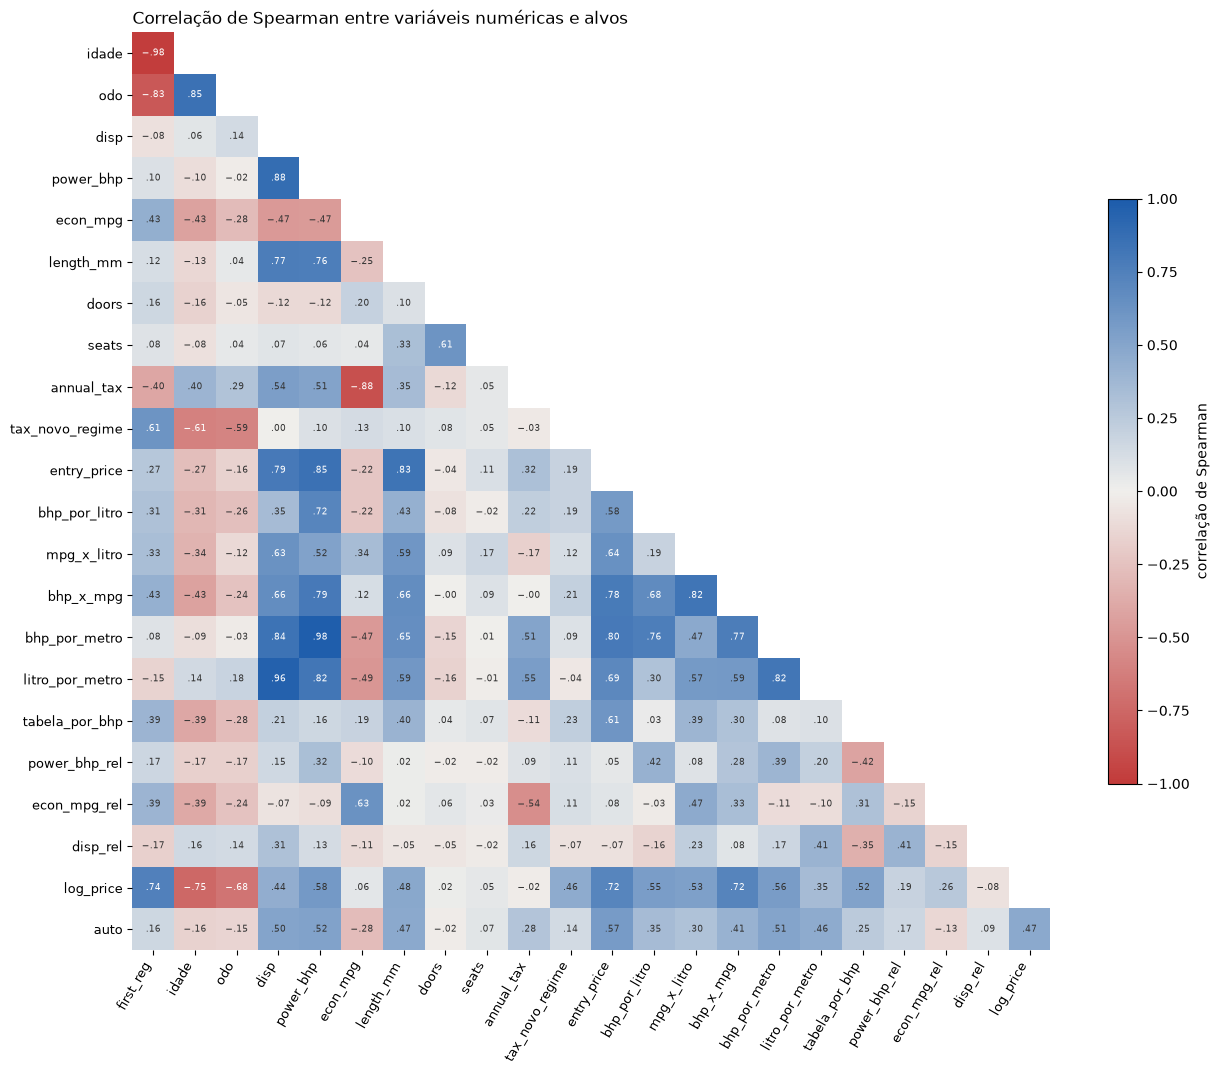

Correlação com os alvos (ordenada pela relação com o preço):


,log_price,auto
idade,-0.75,-0.16
first_reg,0.74,0.16
bhp_x_mpg,0.72,0.41
entry_price,0.72,0.57
odo,-0.68,-0.15
power_bhp,0.58,0.52
bhp_por_metro,0.56,0.51
bhp_por_litro,0.55,0.35
mpg_x_litro,0.53,0.30
tabela_por_bhp,0.52,0.25


In [66]:
from matplotlib.colors import LinearSegmentedColormap

insp = df_feat_insp.assign(log_price=np.log(df_feat_insp["price"]))
colunas_mapa = (["first_reg", "idade", "odo", "disp", "power_bhp", "econ_mpg", "length_mm", "doors", "seats",
                 "annual_tax", "tax_novo_regime", "entry_price"]
                + FEATURES_COMBINADAS + FEATURES_REL_REF + ["log_price", "auto"])
corr = insp[colunas_mapa].corr(method="spearman")
# Só o triângulo de baixo (o de cima é o espelho); sem a 1ª linha e a última coluna, que ficariam vazias
corr_metade = corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1)).iloc[1:, :-1]

# Divergente: azul (positiva) -> cinza (zero) -> vermelho (negativa)
cmap = LinearSegmentedColormap.from_list("div", ["#c23b3a", "#f0efec", "#1c5cab"])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_metade, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(corr_metade.shape[1]), corr_metade.columns, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(corr_metade.shape[0]), corr_metade.index, fontsize=9)
for i in range(corr_metade.shape[0]):
    for j in range(i + 1):
        v = corr_metade.iloc[i, j]
        ax.text(j, i, f"{v:.2f}".replace("0.", ".").replace("-.", "−."), ha="center", va="center",
                fontsize=6.5, color="white" if abs(v) > 0.6 else "#333333")
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_title("Correlação de Spearman entre variáveis numéricas e alvos", loc="left", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.6, label="correlação de Spearman")
plt.tight_layout()
plt.show()

print("Correlação com os alvos (ordenada pela relação com o preço):")
corr.loc[colunas_mapa[:-2], ["log_price", "auto"]].sort_values("log_price", key=abs, ascending=False).round(2)

**Leitura:**

- **Redundâncias:** `idade` × `first_reg` (−0,98) são quase a mesma informação, como a régua já tinha mostrado. `bhp_por_metro` × `power_bhp` (0,98) e `litro_por_metro` × `disp` (0,96) também estão muito correlacionadas, porque o comprimento varia pouco entre carros. Mesmo assim, essas razões melhoraram a régua: **correlação alta não significa informação idêntica**. `annual_tax` × `econ_mpg` (−0,88): o imposto mede emissões, que dependem do consumo.
- **Preço:** as relações mais fortes são idade (−0,75), ano de registro (+0,74), `entry_price` e `bhp_x_mpg` (+0,72) e quilometragem (−0,68). `bhp_x_mpg` é a feature nova com a relação mais forte com o preço.
- **Câmbio:** `entry_price` (+0,57), potência (+0,52), `bhp_por_metro` (+0,51) e cilindrada (+0,50).
- `mpg_x_litro` tem correlação moderada com o câmbio (+0,30), mas foi a feature que, sozinha, mais ajudou o Modelo 2 na régua. Correlação e ganho real respondem a perguntas diferentes, e por isso usamos as duas.

### Resumo das decisões de feature engineering

Diferença = erro com a feature − erro sem (negativo = melhorou). "x/4" = em quantas divisões melhorou.

| # | Feature | Conta | Preço | Câmbio | Evidência |
|---|---|---|---|---|---|
| 1 | `idade` | anúncio − registro | ✗ (só análise de erros) | ✗ | Neutra na régua e no bloco de 2021 |
| 2 | `odo_por_ano` | `odo` ÷ idade | ✗ | ✗ | Piora; câmbio +0,0028 (0/4) |
| 3 | `bhp_por_litro` | potência ÷ cilindrada | ✓ | ✓ | −0,0012 / −0,0034 (4/4 nos dois) |
| 4 | `mpg_x_litro` | consumo × cilindrada | ✓ | ✓ | Câmbio −0,0083 (4/4) |
| 5 | `bhp_x_mpg` | potência × consumo | ✓ | ✓ | Câmbio −0,0079 (4/4) |
| 6 | `bhp_por_metro`, `litro_por_metro` | ÷ comprimento | ✓ | ✓ | Ganhos pequenos (3–4/4) |
| 7 | `tabela_por_bhp` | preço de tabela ÷ potência | ✓ | ✓ | Câmbio −0,0018 (4/4) |
| 3–7 | **as seis juntas** | | ✓ | ✓ | Câmbio −6,8%; preço −2% em carro inédito |
| 8 | `tax_co2` | imposto só no regime antigo | ✗ | ✗ | Melhora em só 2/4 |
| 9 | `n_specs_faltantes` | contagem de faltantes | ✗ | ✓ | Câmbio −0,0006 (3/4) |
| 10 | `entry_price` preenchido + flag | mesmo `ref_code`, ano mais próximo | ✓ | condicional | No câmbio, piora em carro inédito (0/4) |
| 11 | `*_rel` | especificação ÷ mediana do `ref_code` | condicional | condicional | Câmbio −6,4% (conhecido) e +10% (inédito) |

**Mudanças em relação às anotações anteriores:** `idade`, `tax_co2` e `n_specs_faltantes` (no preço) tinham sido aprovadas só pela correlação. A régua mostrou que o modelo já extrai essa informação das colunas originais. Já as features combinadas, que antes se resumiam a `bhp_por_litro`, viraram um grupo de seis.

**Para o escopo de validade:**

- **Carros inéditos são bem mais difíceis.** Erro de 0,262 contra 0,195 no preço e de 0,344 contra 0,241 no câmbio.
- No câmbio, o ganho das features combinadas vale para modelos de carro que já estão na base.
- As features **condicionais** (`*_rel` e, no câmbio, o preenchimento do `entry_price`) só valem a pena se a avaliação tiver principalmente modelos conhecidos. **Pendente para a modelagem:** decidir com a estratégia de validação.

**Próximo passo:** montar as bases de cada modelo (sem duplicatas) e escolher a estratégia de validação: aleatória, temporal (bloco de 2021) ou por `ref_code`.